In [812]:
import pandas as pd
import ast
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pointbiserialr
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
from sklearn.tree import plot_tree
from scipy.stats import pearsonr

In [813]:
df=pd.read_csv("train.csv")
df.head()

,id,belongs_to_collection,budget,genres,homepage,imdb_id,original_language,original_title,overview,popularity,...,release_date,runtime,spoken_languages,status,tagline,title,Keywords,cast,crew,revenue
0,1,"[{'id': 313576, 'name': 'Hot Tub Time Machine ...",14000000,"[{'id': 35, 'name': 'Comedy'}]",NaN,tt2637294,en,Hot Tub Time Machine 2,"When Lou, who has become the ""father of the In...",6.575393,...,2/20/15,93.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The Laws of Space and Time are About to be Vio...,Hot Tub Time Machine 2,"[{'id': 4379, 'name': 'time travel'}, {'id': 9...","[{'cast_id': 4, 'character': 'Lou', 'credit_id...","[{'credit_id': '59ac067c92514107af02c8c8', 'de...",12314651
1,2,"[{'id': 107674, 'name': 'The Princess Diaries ...",40000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,tt0368933,en,The Princess Diaries 2: Royal Engagement,Mia Thermopolis is now a college graduate and ...,8.248895,...,8/6/04,113.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,It can take a lifetime to find true love; she'...,The Princess Diaries 2: Royal Engagement,"[{'id': 2505, 'name': 'coronation'}, {'id': 42...","[{'cast_id': 1, 'character': 'Mia Thermopolis'...","[{'credit_id': '52fe43fe9251416c7502563d', 'de...",95149435
2,3,NaN,3300000,"[{'id': 18, 'name': 'Drama'}]",http://sonyclassics.com/whiplash/,tt2582802,en,Whiplash,"Under the direction of a ruthless instructor, ...",64.299990,...,10/10/14,105.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The road to greatness can take you to the edge.,Whiplash,"[{'id': 1416, 'name': 'jazz'}, {'id': 1523, 'n...","[{'cast_id': 5, 'character': 'Andrew Neimann',...","[{'credit_id': '54d5356ec3a3683ba0000039', 'de...",13092000
3,4,NaN,1200000,"[{'id': 53, 'name': 'Thriller'}, {'id': 18, 'n...",http://kahaanithefilm.com/,tt1821480,hi,Kahaani,Vidya Bagchi (Vidya Balan) arrives in Kolkata ...,3.174936,...,3/9/12,122.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,NaN,Kahaani,"[{'id': 10092, 'name': 'mystery'}, {'id': 1054...","[{'cast_id': 1, 'character': 'Vidya Bagchi', '...","[{'credit_id': '52fe48779251416c9108d6eb', 'de...",16000000
4,5,NaN,0,"[{'id': 28, 'name': 'Action'}, {'id': 53, 'nam...",NaN,tt1380152,ko,마린보이,Marine Boy is the story of a former national s...,1.148070,...,2/5/09,118.0,"[{'iso_639_1': 'ko', 'name': '한국어/조선말'}]",Released,NaN,Marine Boy,NaN,"[{'cast_id': 3, 'character': 'Chun-soo', 'cred...","[{'credit_id': '52fe464b9251416c75073b43', 'de...",3923970


In [814]:
df.shape

(3000, 23)

In [815]:
df.describe()

,id,budget,popularity,runtime,revenue
count,3000.000000,3.000000e+03,3000.000000,2998.000000,3.000000e+03
mean,1500.500000,2.253133e+07,8.463274,107.856571,6.672585e+07
std,866.169729,3.702609e+07,12.104000,22.086434,1.375323e+08
min,1.000000,0.000000e+00,0.000001,0.000000,1.000000e+00
25%,750.750000,0.000000e+00,4.018053,94.000000,2.379808e+06
50%,1500.500000,8.000000e+06,7.374861,104.000000,1.680707e+07
75%,2250.250000,2.900000e+07,10.890983,118.000000,6.891920e+07
max,3000.000000,3.800000e+08,294.337037,338.000000,1.519558e+09


In [816]:
df.describe(include='object')

,belongs_to_collection,genres,homepage,imdb_id,original_language,original_title,overview,poster_path,production_companies,production_countries,release_date,spoken_languages,status,tagline,title,Keywords,cast,crew
count,604,2993,946,3000,3000,3000,2992,2999,2844,2945,3000,2980,3000,2403,3000,2724,2987,2984
unique,422,872,941,3000,36,2975,2992,2999,2383,321,2398,401,2,2400,2969,2648,2975,2984
top,"[{'id': 645, 'name': 'James Bond Collection', ...","[{'id': 18, 'name': 'Drama'}]",http://www.transformersmovie.com/,tt2637294,en,Joshua,"When Lou, who has become the ""father of the In...",/tQtWuwvMf0hCc2QR2tkolwl7c3c.jpg,"[{'name': 'Paramount Pictures', 'id': 4}]","[{'iso_3166_1': 'US', 'name': 'United States o...",9/10/10,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Based on a true story.,The Magnificent Seven,"[{'id': 10183, 'name': 'independent film'}]",[],"[{'credit_id': '59ac067c92514107af02c8c8', 'de..."
freq,16,266,4,1,2575,2,1,1,51,1752,5,1817,2996,3,2,27,13,1


In [817]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     3000 non-null   int64  
 1   belongs_to_collection  604 non-null    object 
 2   budget                 3000 non-null   int64  
 3   genres                 2993 non-null   object 
 4   homepage               946 non-null    object 
 5   imdb_id                3000 non-null   object 
 6   original_language      3000 non-null   object 
 7   original_title         3000 non-null   object 
 8   overview               2992 non-null   object 
 9   popularity             3000 non-null   float64
 10  poster_path            2999 non-null   object 
 11  production_companies   2844 non-null   object 
 12  production_countries   2945 non-null   object 
 13  release_date           3000 non-null   object 
 14  runtime                2998 non-null   float64
 15  spok

# Data preprocessing

In [818]:
df.columns

Index(['id', 'belongs_to_collection', 'budget', 'genres', 'homepage',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'production_companies',
       'production_countries', 'release_date', 'runtime', 'spoken_languages',
       'status', 'tagline', 'title', 'Keywords', 'cast', 'crew', 'revenue'],
      dtype='object')

## Missing Value Analysis

In [819]:
print(df.isnull().sum())

id                          0
belongs_to_collection    2396
budget                      0
genres                      7
homepage                 2054
imdb_id                     0
original_language           0
original_title              0
overview                    8
popularity                  0
poster_path                 1
production_companies      156
production_countries       55
release_date                0
runtime                     2
spoken_languages           20
status                      0
tagline                   597
title                       0
Keywords                  276
cast                       13
crew                       16
revenue                     0
dtype: int64


In [820]:
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(missing[missing > 0]) 

belongs_to_collection    79.866667
homepage                 68.466667
tagline                  19.900000
Keywords                  9.200000
production_companies      5.200000
production_countries      1.833333
spoken_languages          0.666667
crew                      0.533333
cast                      0.433333
overview                  0.266667
genres                    0.233333
runtime                   0.066667
poster_path               0.033333
dtype: float64


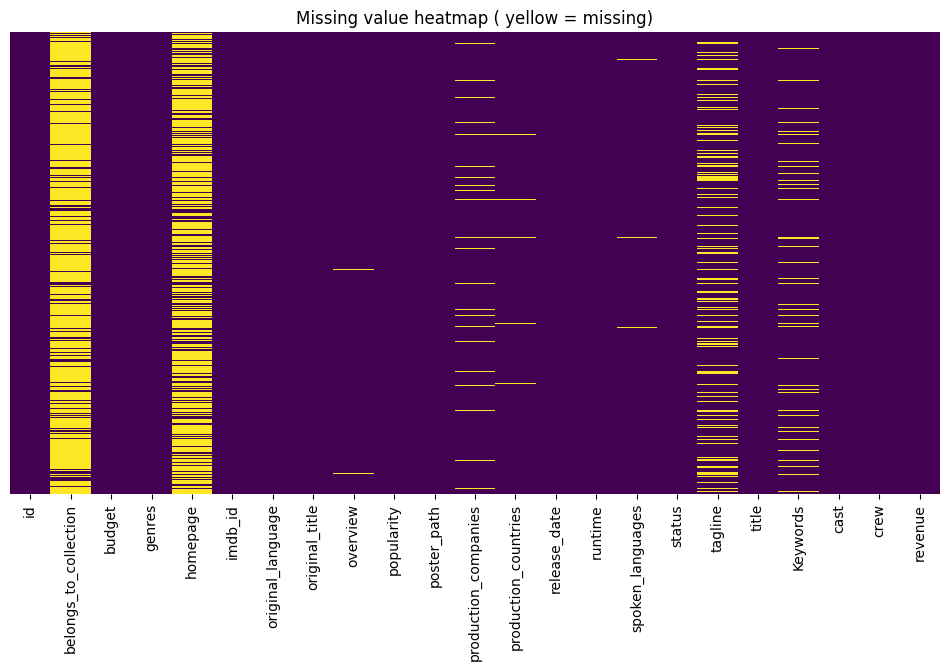

In [821]:
plt.figure(figsize=(12, 6))
sns.heatmap(
    df.isnull(),          
    cbar=False,           
    yticklabels=False,    
    cmap='viridis'        
)
plt.title('Missing value heatmap ( yellow = missing)')
plt.show()

In [822]:
df['runtime'].fillna(df['runtime'].median(), inplace=True)

/var/folders/xw/5yjdwh314qq6ntp9fy6rpyfm0000gn/T/ipykernel_75407/530401232.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['runtime'].fillna(df['runtime'].median(), inplace=True)


## Duplicate

In [823]:
df.duplicated().sum()

np.int64(0)

In [824]:
print("Zero budget:", (df['budget'] == 0).sum())
print("Zero revenue:", (df['revenue'] == 0).sum())

Zero budget: 812
Zero revenue: 0


In [825]:
median = df.loc[df['budget']> 0, 'budget'].median()
df["budget"] = df["budget"].mask(df["budget"] == 0, median)

columns='id', 'belongs_to_collection', 'budget', 'genres', 'homepage',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'production_companies',
       'production_countries', 'release_date', 'runtime', 'spoken_languages',
       'status', 'tagline', 'title', 'Keywords', 'cast', 'crew', 'revenue'

In [826]:
df.iloc[0]

id                                                                       1
belongs_to_collection    [{'id': 313576, 'name': 'Hot Tub Time Machine ...
budget                                                            14000000
genres                                      [{'id': 35, 'name': 'Comedy'}]
homepage                                                               NaN
imdb_id                                                          tt2637294
original_language                                                       en
original_title                                      Hot Tub Time Machine 2
overview                 When Lou, who has become the "father of the In...
popularity                                                        6.575393
poster_path                               /tQtWuwvMf0hCc2QR2tkolwl7c3c.jpg
production_companies     [{'name': 'Paramount Pictures', 'id': 4}, {'na...
production_countries     [{'iso_3166_1': 'US', 'name': 'United States o...
release_date             

In [827]:
df['belongs_to_collection'].iloc[0]

"[{'id': 313576, 'name': 'Hot Tub Time Machine Collection', 'poster_path': '/iEhb00TGPucF0b4joM1ieyY026U.jpg', 'backdrop_path': '/noeTVcgpBiD48fDjFVic1Vz7ope.jpg'}]"

In [828]:
df['belongs_to_collection'].values

array(["[{'id': 313576, 'name': 'Hot Tub Time Machine Collection', 'poster_path': '/iEhb00TGPucF0b4joM1ieyY026U.jpg', 'backdrop_path': '/noeTVcgpBiD48fDjFVic1Vz7ope.jpg'}]",
       "[{'id': 107674, 'name': 'The Princess Diaries Collection', 'poster_path': '/wt5AMbxPTS4Kfjx7Fgm149qPfZl.jpg', 'backdrop_path': '/zSEtYD77pKRJlUPx34BJgUG9v1c.jpg'}]",
       nan, ..., nan, nan, nan], dtype=object)

In [829]:
df['genres'].values

array(["[{'id': 35, 'name': 'Comedy'}]",
       "[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'name': 'Drama'}, {'id': 10751, 'name': 'Family'}, {'id': 10749, 'name': 'Romance'}]",
       "[{'id': 18, 'name': 'Drama'}]", ...,
       "[{'id': 80, 'name': 'Crime'}, {'id': 28, 'name': 'Action'}, {'id': 9648, 'name': 'Mystery'}, {'id': 53, 'name': 'Thriller'}]",
       "[{'id': 35, 'name': 'Comedy'}, {'id': 10749, 'name': 'Romance'}]",
       "[{'id': 53, 'name': 'Thriller'}, {'id': 28, 'name': 'Action'}, {'id': 9648, 'name': 'Mystery'}]"],
      dtype=object)

In [830]:
df['production_companies'].iloc[0]

"[{'name': 'Paramount Pictures', 'id': 4}, {'name': 'United Artists', 'id': 60}, {'name': 'Metro-Goldwyn-Mayer (MGM)', 'id': 8411}]"

In [831]:
def extract_collection_features(x):
    if isinstance(x, str):
        try:
            x = ast.literal_eval(x)
        except:
            return pd.Series([None])
    
    
    if isinstance(x, list) and len(x) > 0:
        return pd.Series([                    
            x[0].get('name')       
        ])
    
    return pd.Series([None])

column created:has_collection

In [832]:
df['collection_name']=df['belongs_to_collection'].apply(extract_collection_features)

In [833]:
df['has_collection'] = df['collection_name'].apply(lambda x: 1 if x!=None  else 0)

In [834]:
def extract_names(x):
    if isinstance(x, str):
        try:
            x = ast.literal_eval(x)
        except:
            return []
    
    if isinstance(x, list):
        return [i.get('name') for i in x if isinstance(i, dict) and 'name' in i]
    
    return []

In [835]:
df['genres_list']=df['genres'].apply(extract_names)

In [836]:
df['genre_count'] = df['genres_list'].apply(len)

In [837]:
df['has_homepage'] = df['homepage'].notnull().astype(int)

In [838]:
df['original_language'].value_counts()

original_language
en    2575
fr      78
ru      47
es      43
hi      42
ja      37
it      24
cn      20
ko      20
zh      19
de      18
ta      16
sv       8
nl       6
pt       6
fa       5
da       5
ro       4
hu       3
tr       3
no       2
ml       2
pl       2
te       2
fi       2
ur       1
he       1
el       1
ar       1
nb       1
vi       1
mr       1
cs       1
sr       1
bn       1
id       1
Name: count, dtype: int64

In [839]:
top_langs = df['original_language'].value_counts().index[:5]

df['original_language'] = df['original_language'].apply(
    lambda x: x if x in top_langs else 'other'
)

In [840]:
df['is_english'] = df['original_language'].apply(lambda x: 1 if x == 'en' else 0)

In [841]:
df = pd.get_dummies(df, columns=['original_language'], drop_first=True,dtype=int)

In [842]:
df['overview_length'] = df['overview'].fillna('').apply(len)
df['overview_word_count'] = df['overview'].fillna('').apply(lambda x: len(x.split()))

In [843]:
df['company_names'] = df['production_companies'].apply(extract_names)

In [844]:
all_companies = df['company_names'].explode()

freq = all_companies.value_counts()

df['company_score'] = df['company_names'].apply(
    lambda x: sum(freq.get(i, 0) for i in x)
)

In [845]:
freq

company_names
Warner Bros.                              202
Universal Pictures                        188
Paramount Pictures                        161
Twentieth Century Fox Film Corporation    138
Columbia Pictures                          91
                                         ... 
Videofilms                                  1
Riofilm                                     1
Zero Gravity Management                     1
Pierce/Williams Entertainment               1
Quick Six Entertainment                     1
Name: count, Length: 3695, dtype: int64

In [846]:
top_company=['Warner Bros.','Universal Pictures','Paramount Pictures','Twentieth Century Fox Film Corporation']

In [847]:
def is_top_company(companies):
    if isinstance(companies, list):
        return int(any(c in top_company for c in companies))
    return 0

In [848]:
df['is_top_company'] = df['company_names'].apply(is_top_company)

In [849]:
def top_company_score(company):
    if not isinstance(company, list):
        return 0
    return sum(c in top_company for c in company[:5])

In [850]:
df['top_company_score'] = df['company_names'].apply(top_company_score)

In [851]:
df['country_names'] = df['production_countries'].apply(extract_names)

In [852]:
def is_usa(country_list):
    if not isinstance(country_list, list):
        return 0
    return int('United States of America' in country_list)

df['usa_produced'] = df['country_names'].apply(is_usa)

In [853]:
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year
df['release_month'] = df['release_date'].dt.month
df['release_dayofweek'] = df['release_date'].dt.dayofweek

df["season"] = df["release_month"]%4

/var/folders/xw/5yjdwh314qq6ntp9fy6rpyfm0000gn/T/ipykernel_75407/644218548.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')


In [854]:
df['spoken_languages_name']=df['spoken_languages'].apply(extract_names)

In [855]:
df['num_spoken_languages'] = df['spoken_languages_name'].apply(lambda x: len(x))

In [856]:
df['spoken_languages_name'].value_counts()

spoken_languages_name
[English]                                                1817
[English, Español]                                         86
[English, Français]                                        77
[Pусский]                                                  45
[Français]                                                 40
                                                         ... 
[العربية, English, Français, Italiano]                      1
[Český, Deutsch]                                            1
[English, Français, Italiano, Pусский, Español]             1
[اردو]                                                      1
[български език, English, Français, Pусский, Español]       1
Name: count, Length: 392, dtype: int64

In [857]:
def is_english(languages):
    if not isinstance(languages, list):
        return 0
    return int('English' in languages)

In [858]:
df['has_english'] = df['spoken_languages_name'].apply(is_english)

In [859]:
df['has_keywords'] = df['Keywords'].apply(lambda x: 1 if type(x) == str else 0)

In [860]:
df['keyword_names'] = df['Keywords'].apply(extract_names)

In [861]:
all_keywords = df['keyword_names'].explode()
freq = all_keywords.value_counts()

df['keyword_score'] = df['keyword_names'].apply(
    lambda x: sum(freq.get(i, 0) for i in x)
)

In [862]:
df['cast_names'] = df['cast'].apply(extract_names)

In [863]:
all_cast = df['cast_names'].explode()

In [864]:
freq = all_cast.value_counts()

df['cast_score'] = df['cast_names'].apply(
    lambda x: sum(freq.get(i, 0) for i in x)
)

In [865]:
def extract_director(x):
    if isinstance(x, str):
        try:
            x = ast.literal_eval(x)
        except:
            return None
    
    if isinstance(x, list):
        for i in x:
            if isinstance(i, dict) and i.get('job') == 'Director':
                return i.get('name')   # ✅ string
    
    return None

In [866]:
df['director'] = df['crew'].apply(extract_director)

In [867]:
freq = df['director'].value_counts()
df['director_score'] = df['director'].map(freq)

In [868]:
df.drop(columns=['belongs_to_collection','id','collection_name','genres_list','genres','homepage', 'imdb_id','original_title','overview','poster_path','production_companies','company_names','production_countries', 'release_date','status','tagline','title','keyword_names','Keywords','cast_names','country_names','spoken_languages_name','cast','crew','director','spoken_languages',], inplace=True)

In [869]:
df.head()

,budget,popularity,runtime,revenue,has_collection,genre_count,has_homepage,is_english,original_language_es,original_language_fr,...,release_year,release_month,release_dayofweek,season,num_spoken_languages,has_english,has_keywords,keyword_score,cast_score,director_score
0,14000000,6.575393,93.0,12314651,1,1,0,1,0,0,...,2015,2,4,2,1,1,1,227,101,3.0
1,40000000,8.248895,113.0,95149435,1,4,0,1,0,0,...,2004,8,4,0,1,1,1,34,95,6.0
2,3300000,64.299990,105.0,13092000,0,1,1,1,0,0,...,2014,10,4,2,1,1,1,161,108,1.0
3,1200000,3.174936,122.0,16000000,0,2,1,0,0,0,...,2012,3,4,3,2,1,1,49,11,1.0
4,16000000,1.148070,118.0,3923970,0,2,0,0,0,0,...,2009,2,3,2,1,0,0,0,5,1.0


# EDA

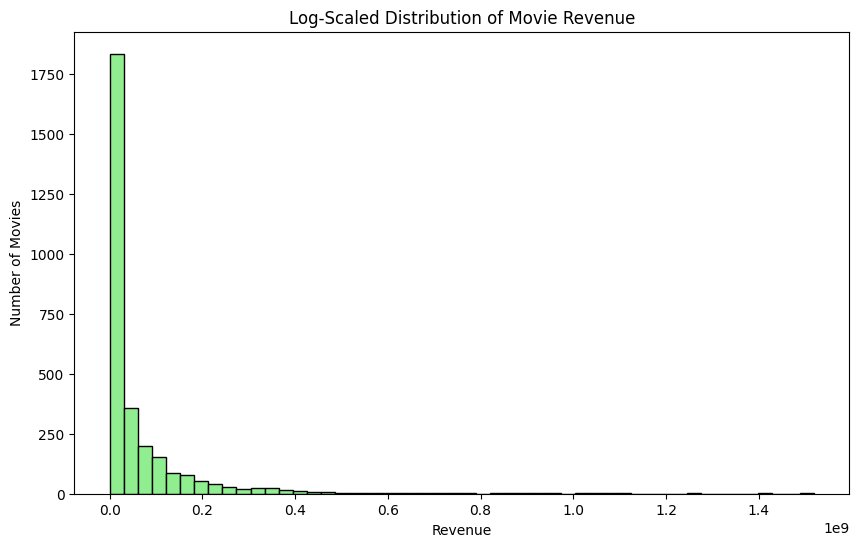

In [870]:
# revenue histogram
plt.figure(figsize=(10,6))
plt.hist(df['revenue'], bins=50, color='lightgreen', edgecolor='black')
plt.title('Log-Scaled Distribution of Movie Revenue')
plt.xlabel('Revenue')
plt.ylabel('Number of Movies')
plt.show()

● Majority of movies have moderate to high revenue
● Few movies have very low revenue, which appear as a small tail on the left side of the histogram

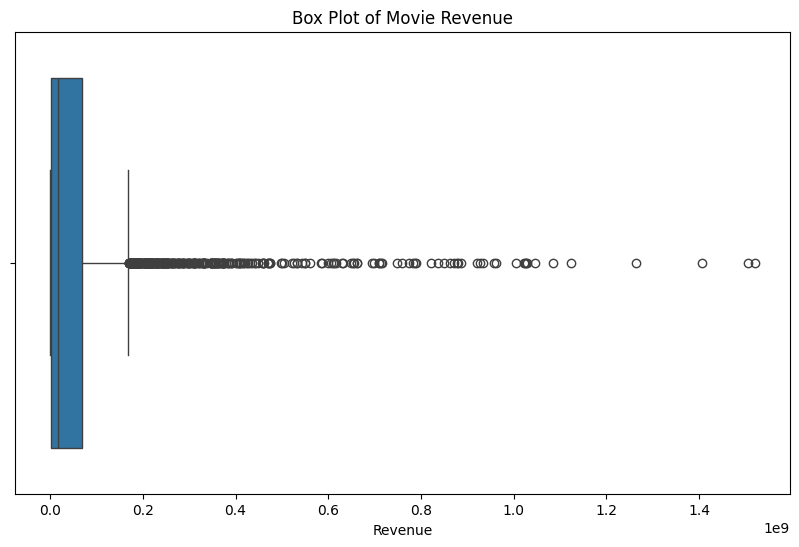

In [871]:
plt.figure(figsize=(10,6))
sns.boxplot(x=df['revenue'])  # log1p avoids log(0)
plt.xlabel('Revenue')
plt.title('Box Plot of Movie Revenue')
plt.show()

# Univariate Analysis 

In [872]:
df.columns

Index(['budget', 'popularity', 'runtime', 'revenue', 'has_collection',
       'genre_count', 'has_homepage', 'is_english', 'original_language_es',
       'original_language_fr', 'original_language_hi',
       'original_language_other', 'original_language_ru', 'overview_length',
       'overview_word_count', 'company_score', 'is_top_company',
       'top_company_score', 'usa_produced', 'release_year', 'release_month',
       'release_dayofweek', 'season', 'num_spoken_languages', 'has_english',
       'has_keywords', 'keyword_score', 'cast_score', 'director_score'],
      dtype='object')

'budget', 'popularity', 'runtime', 'revenue', 'has_collection',
       'genre_count', 'has_homepage', 'is_english', 'original_language_es',
       'original_language_fr', 'original_language_hi',
       'original_language_other', 'original_language_ru', 'overview_length',
       'overview_word_count', 'company_score', 'is_top_company',
       'top_company_score', 'usa_produced', 'release_year', 'release_month',
       'release_dayofweek', 'season', 'num_spoken_languages', 'has_english',
       'has_keywords', 'keyword_score', 'cast_score', 'director_score'],
      dtype='object'

# Summary Statistics

In [873]:
# Numerical summary
num_cols = ['budget','popularity','runtime','revenue','overview_length','genre_count',
            'overview_word_count','company_score','top_company_score', 'director_score','keyword_score','cast_score','director_score']
df[num_cols].describe()

,budget,popularity,runtime,revenue,overview_length,genre_count,overview_word_count,company_score,top_company_score,director_score,keyword_score,cast_score,director_score
count,3.000000e+03,3000.000000,3000.000000,3.000000e+03,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,2984.000000,3000.000000,3000.000000,2984.000000
mean,2.686200e+07,8.463274,107.854000,6.672585e+07,307.805667,2.503667,52.535333,66.811667,0.229000,2.534853,117.632667,69.977000,2.534853
std,3.501810e+07,12.104000,22.079293,1.375323e+08,167.023568,1.117021,28.383328,78.081900,0.423421,2.009563,119.550968,51.426919,2.009563
min,1.000000e+00,0.000001,0.000000,1.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
25%,9.000000e+06,4.018053,94.000000,2.379808e+06,178.000000,2.000000,31.000000,4.000000,0.000000,1.000000,28.000000,31.000000,1.000000
50%,1.600000e+07,7.374861,104.000000,1.680707e+07,285.000000,2.000000,49.000000,30.000000,0.000000,2.000000,82.000000,60.000000,2.000000
75%,2.900000e+07,10.890983,118.000000,6.891920e+07,395.250000,3.000000,68.000000,102.000000,0.000000,3.000000,175.000000,96.000000,3.000000
max,3.800000e+08,294.337037,338.000000,1.519558e+09,1007.000000,7.000000,177.000000,375.000000,2.000000,11.000000,1259.000000,461.000000,11.000000


In [874]:
cat_cols = ['has_collection','has_homepage','is_english','original_language_es','original_language_fr',
            'original_language_hi','original_language_other','original_language_ru','is_top_company','usa_produced','has_english','has_keywords']

df[cat_cols].describe()

,has_collection,has_homepage,is_english,original_language_es,original_language_fr,original_language_hi,original_language_other,original_language_ru,is_top_company,usa_produced,has_english,has_keywords
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.00000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,0.201333,0.315333,0.858333,0.014333,0.026000,0.01400,0.071667,0.015667,0.228333,0.760667,0.872667,0.908000
std,0.401063,0.464726,0.348766,0.118881,0.159162,0.11751,0.257978,0.124203,0.419829,0.426748,0.333402,0.289074
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,1.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
50%,0.000000,0.000000,1.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
75%,0.000000,1.000000,1.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


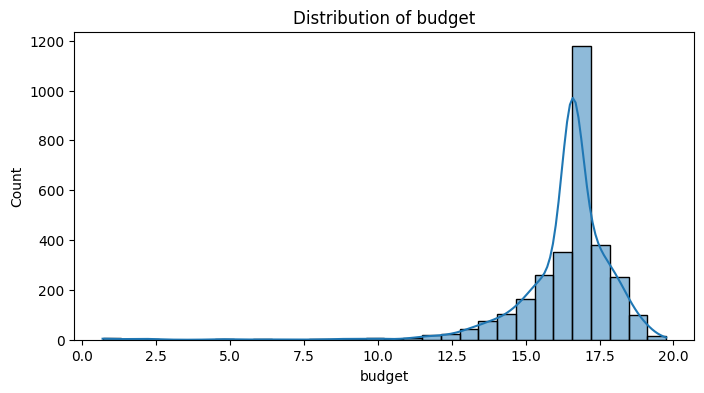

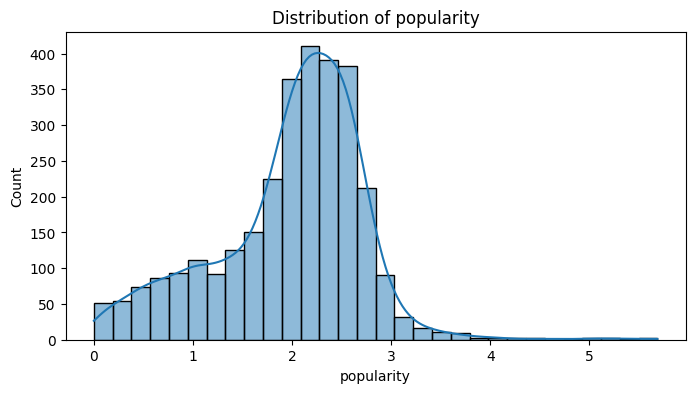

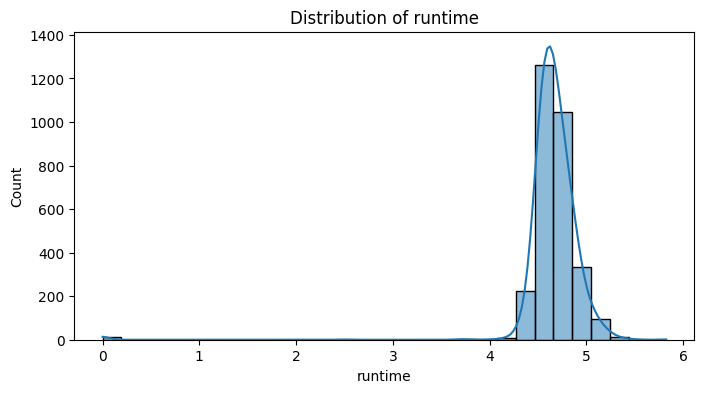

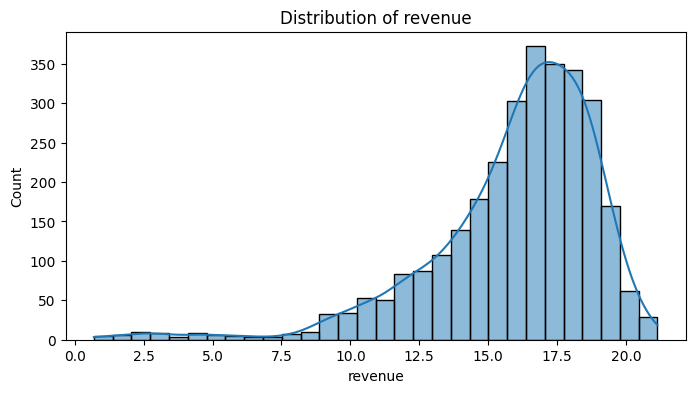

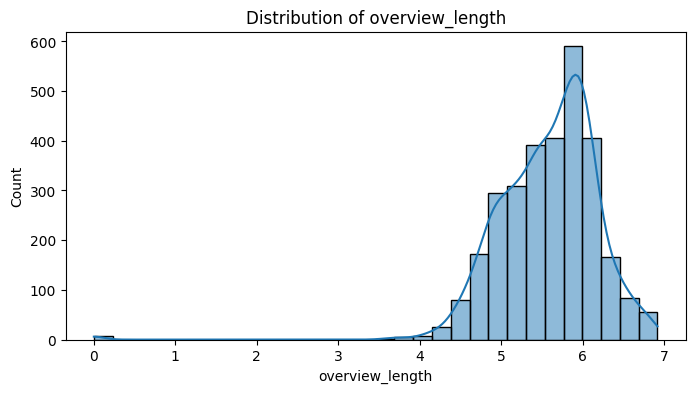

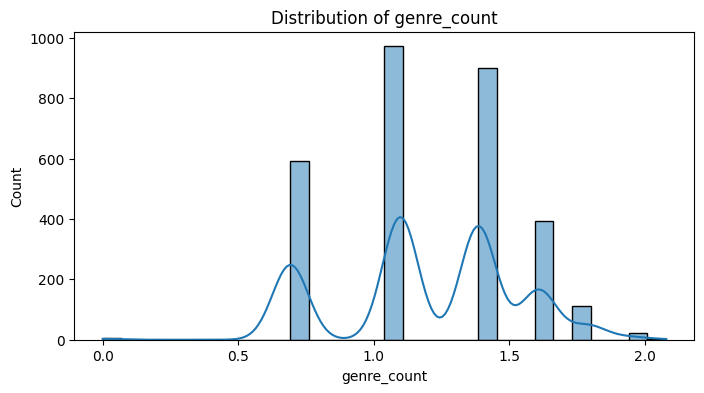

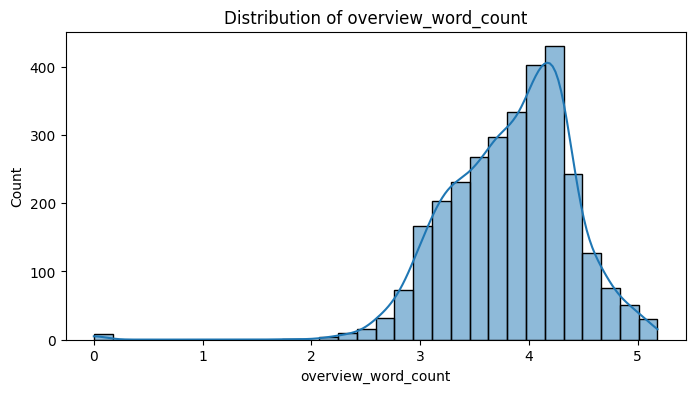

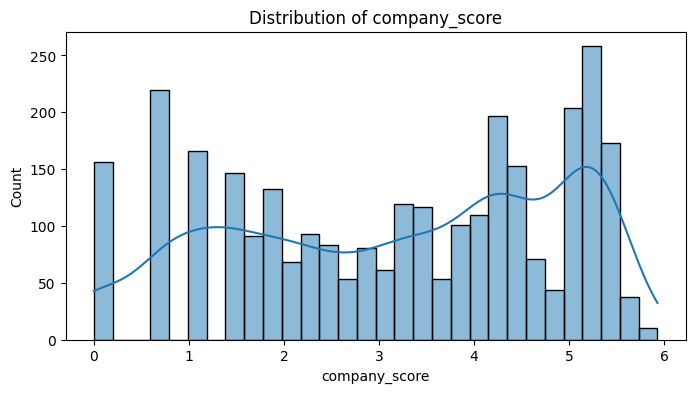

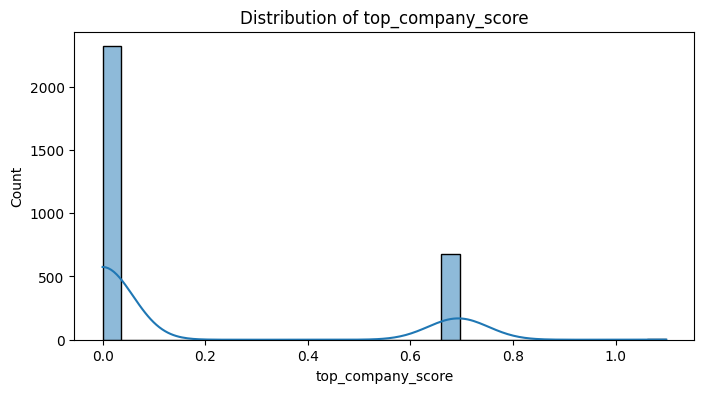

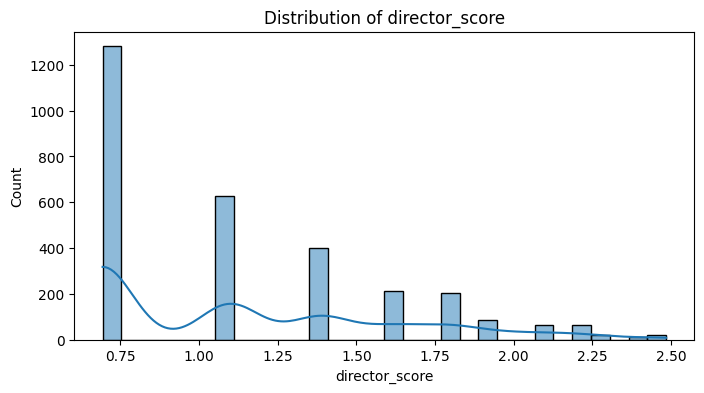

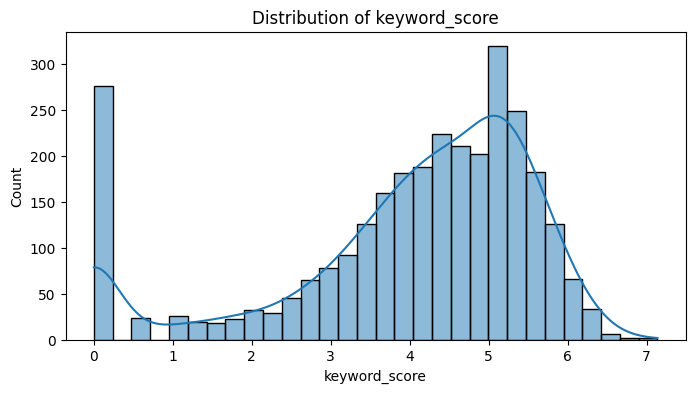

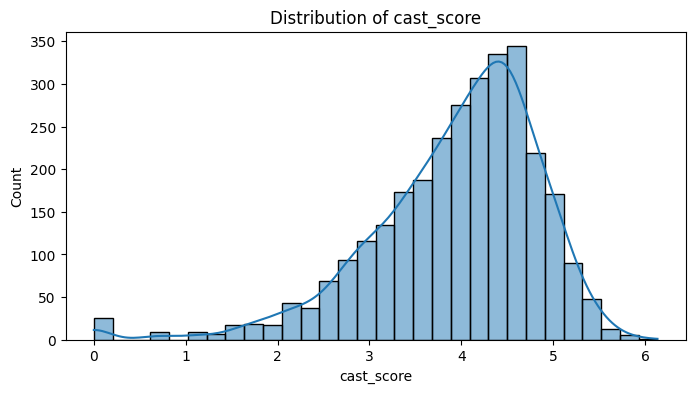

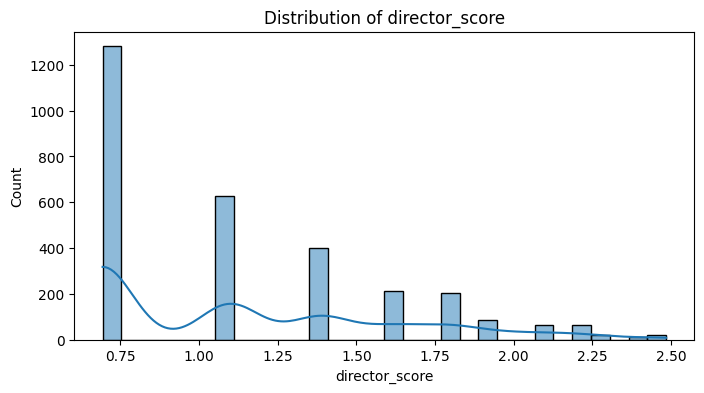

In [875]:
for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(np.log1p(df[col]), kde=True,bins=30)
    plt.title(f'Distribution of {col}')
    plt.show()

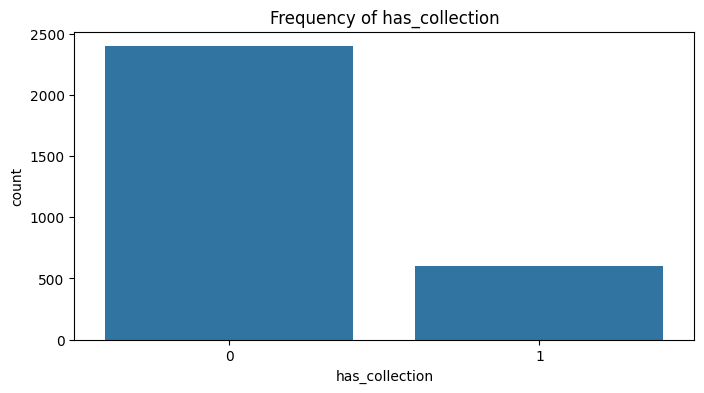

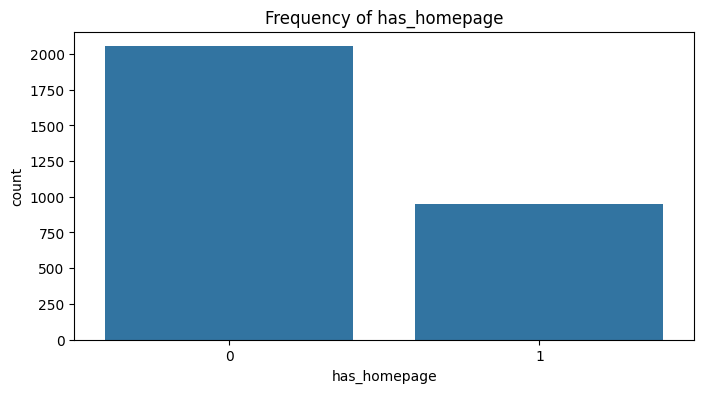

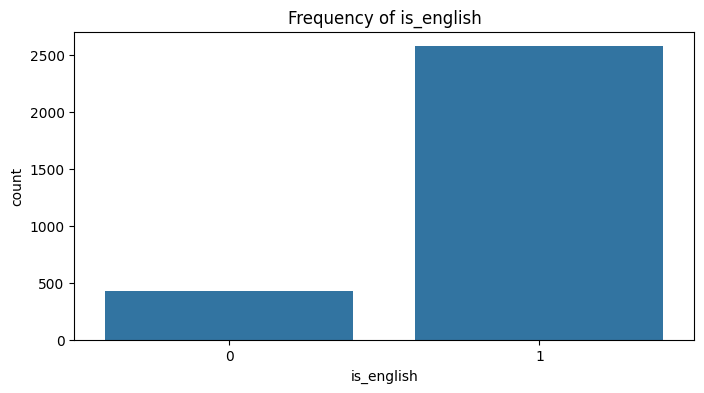

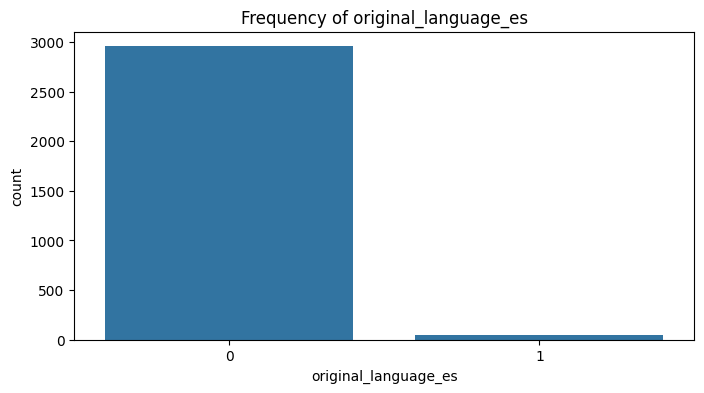

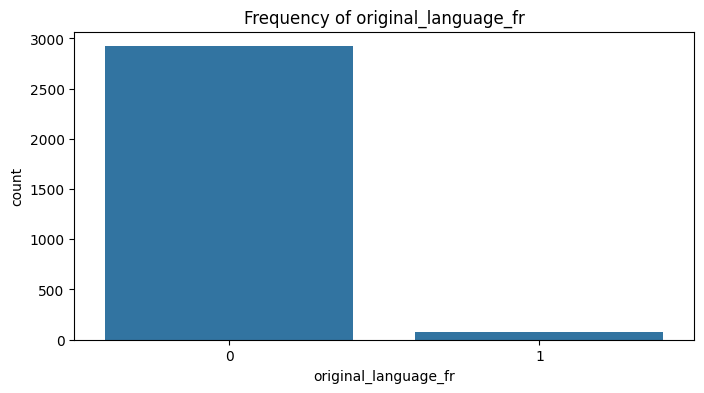

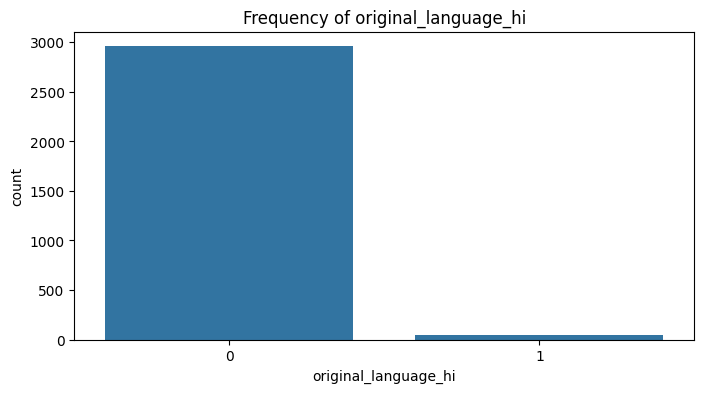

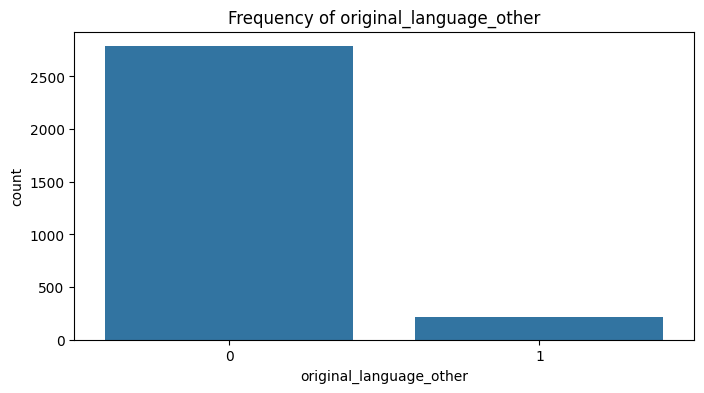

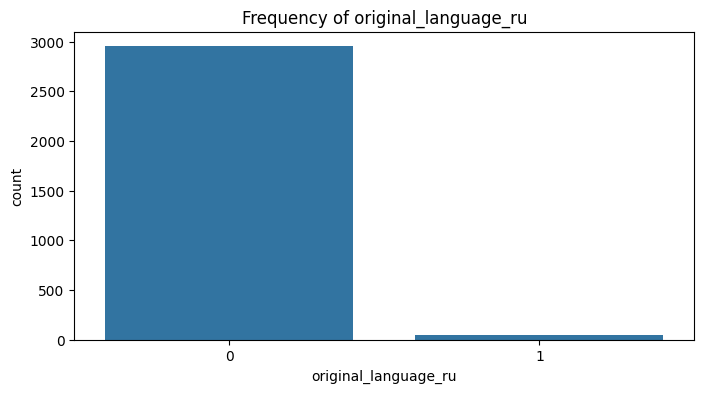

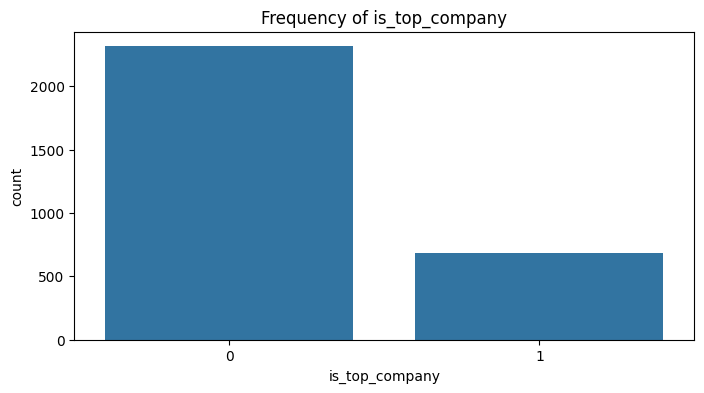

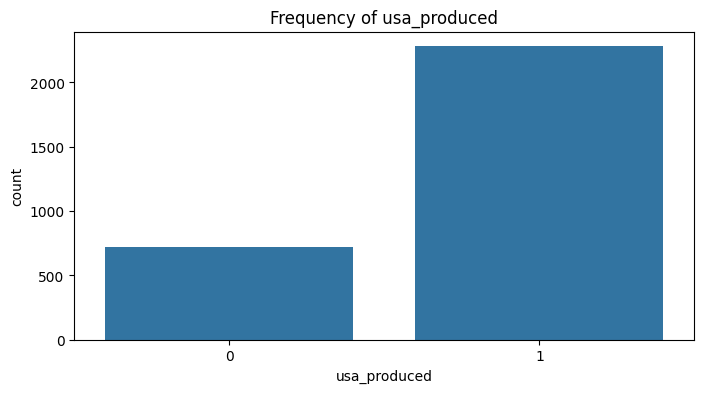

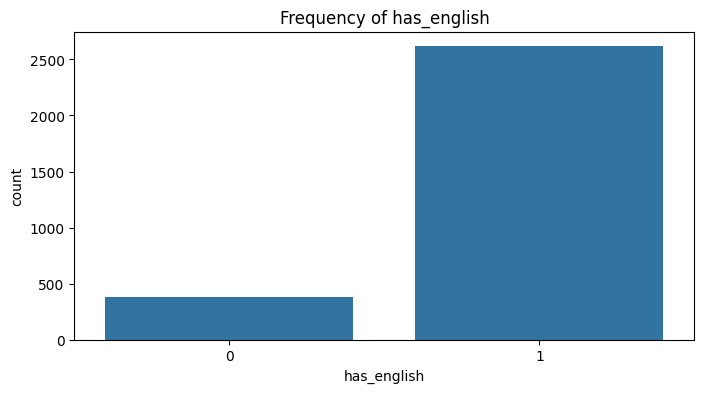

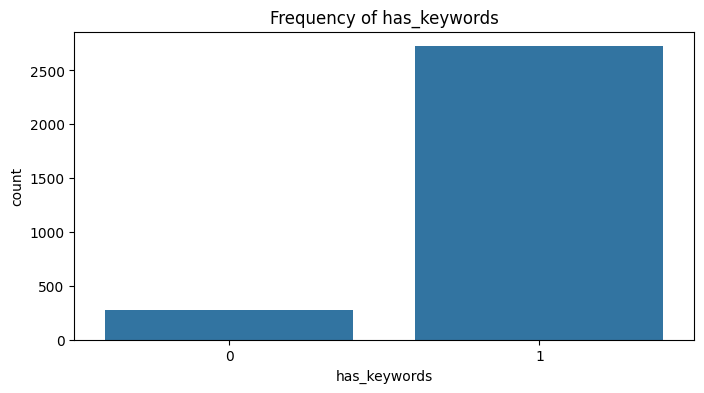

In [876]:
for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=df[col])
    plt.title(f'Frequency of {col}')
    plt.show()

# Bivariate Analysis 

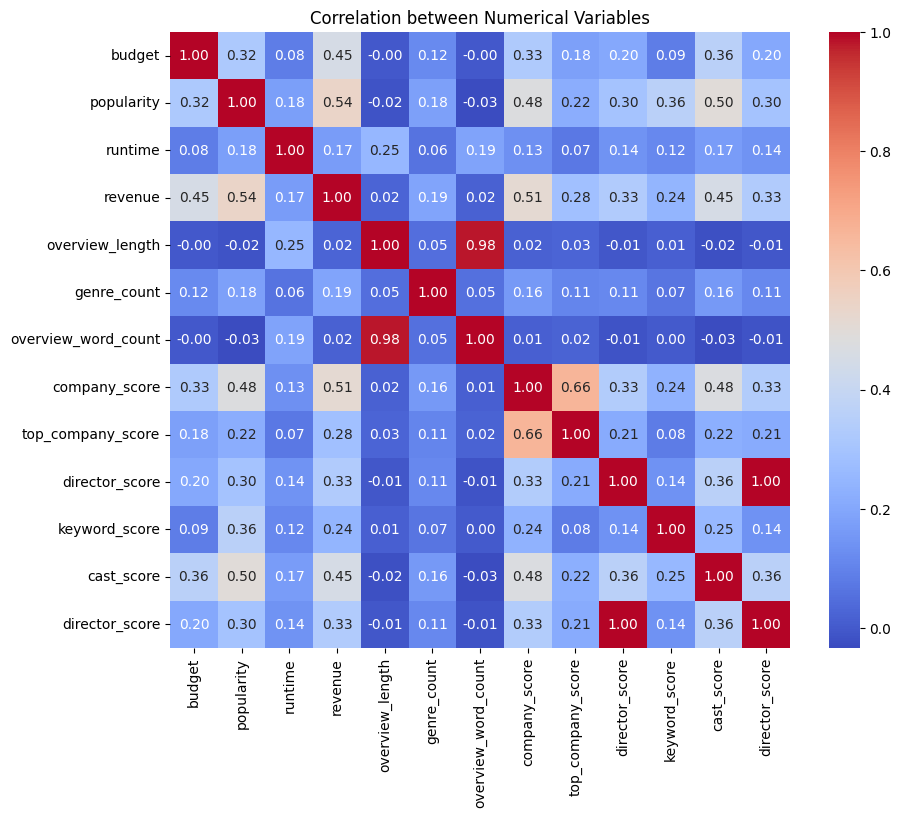

In [877]:
plt.figure(figsize=(10,8))
sns.heatmap( np.log1p(df[num_cols]).corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation between Numerical Variables")
plt.show()

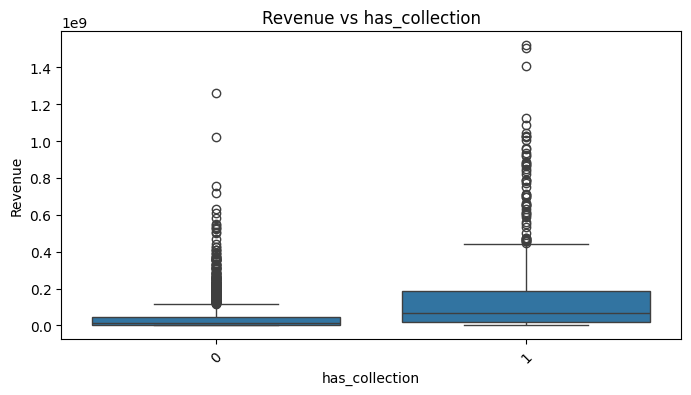

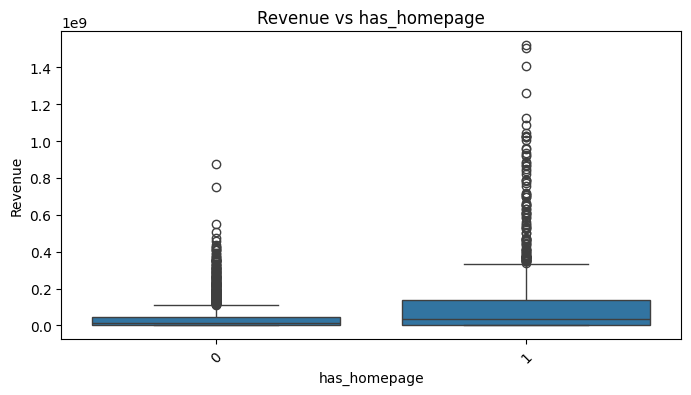

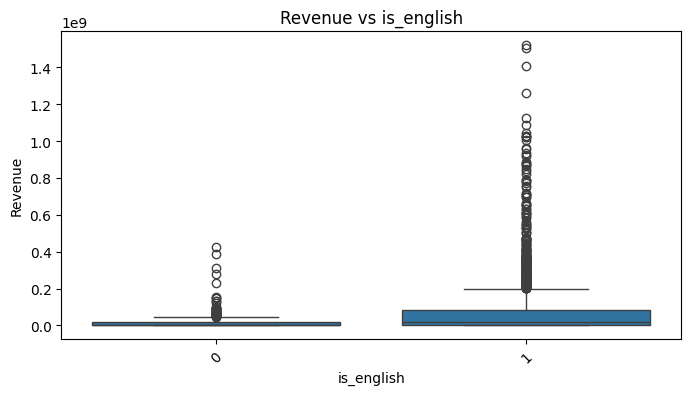

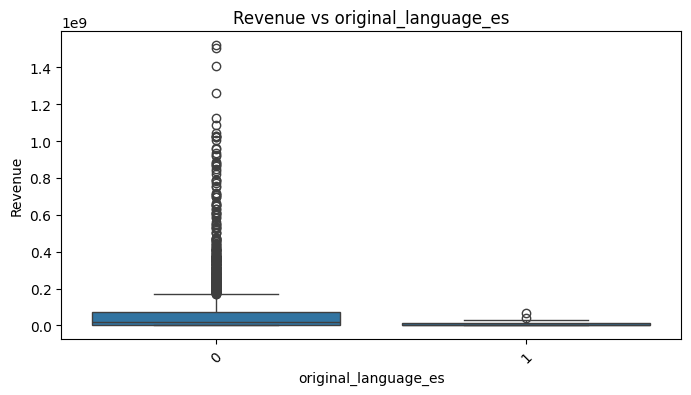

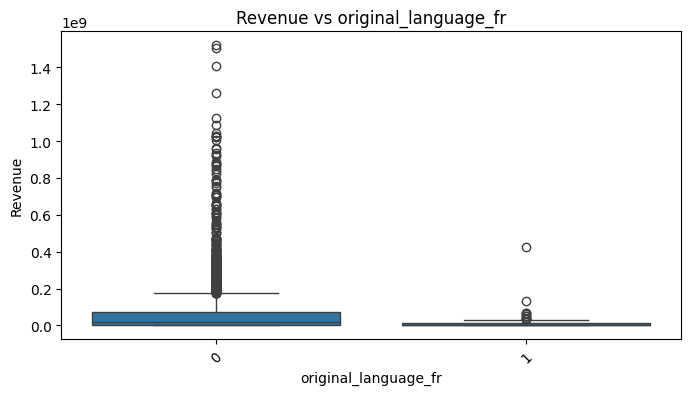

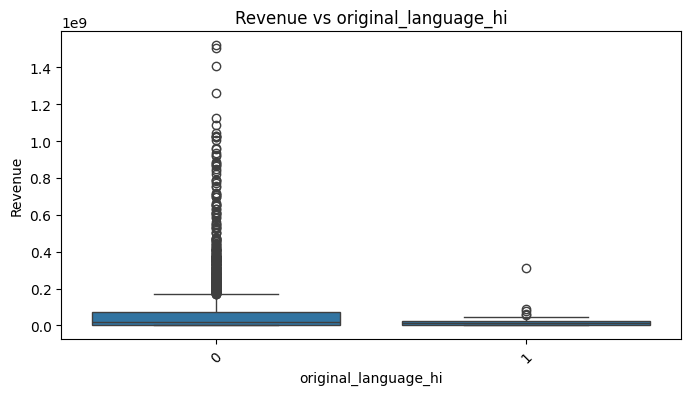

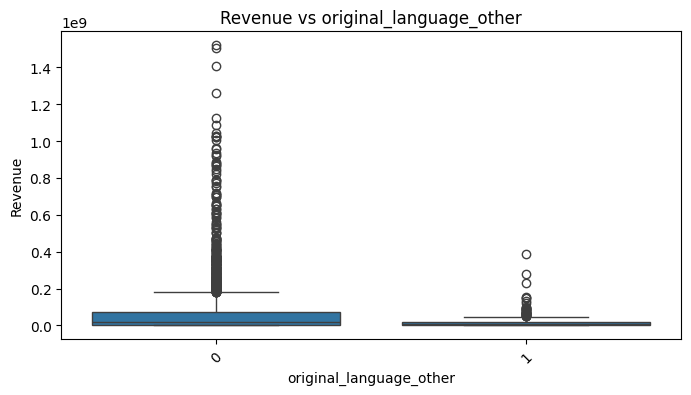

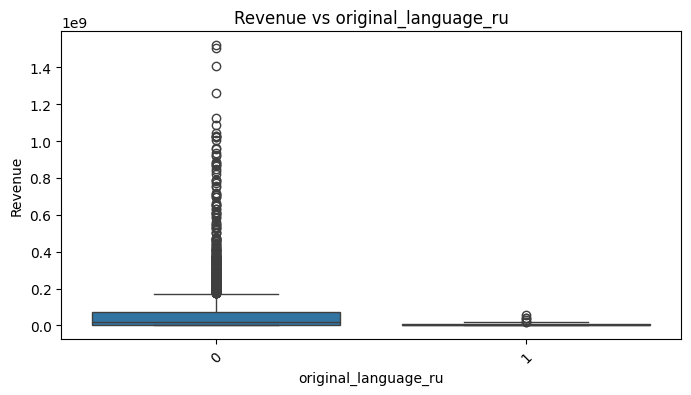

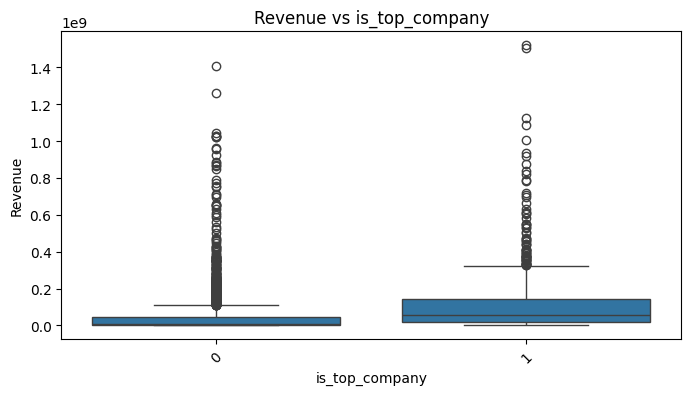

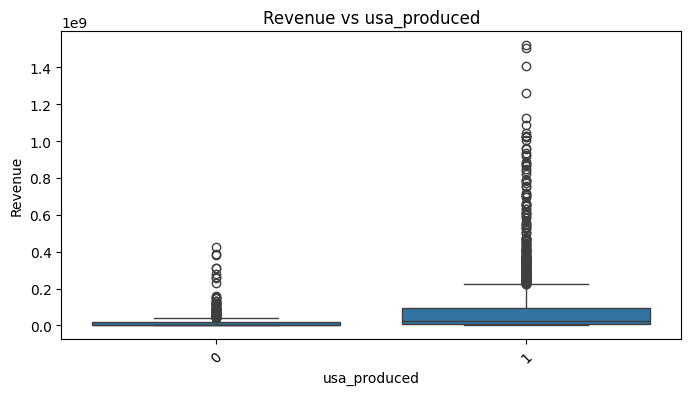

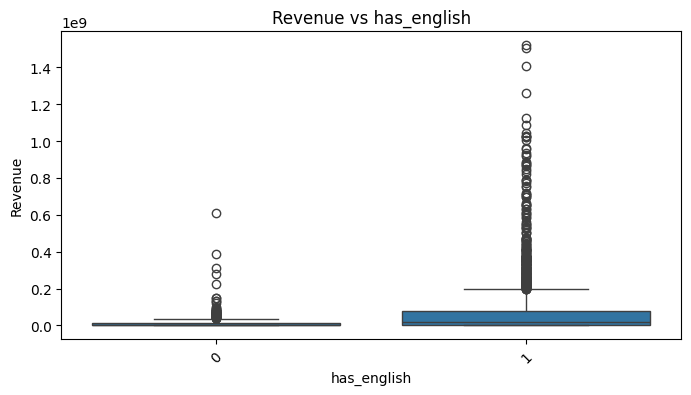

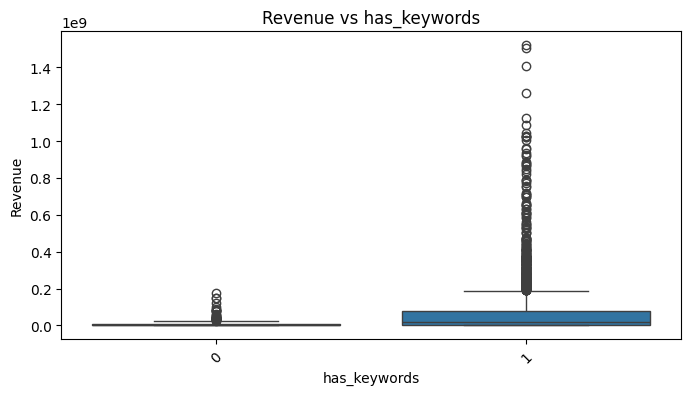

In [878]:
target = 'revenue'

for col in cat_cols:
    plt.figure(figsize=(8,4))
    # Use log scale for skewed revenue
    sns.boxplot(x=col, y=df[target], data=df)
    plt.title(f'Revenue vs {col}')
    plt.ylabel('Revenue')
    plt.xticks(rotation=45)
    plt.show()

In [879]:
subset_cols = ['budget','popularity','company_score','revenue','cast_score','director_score']

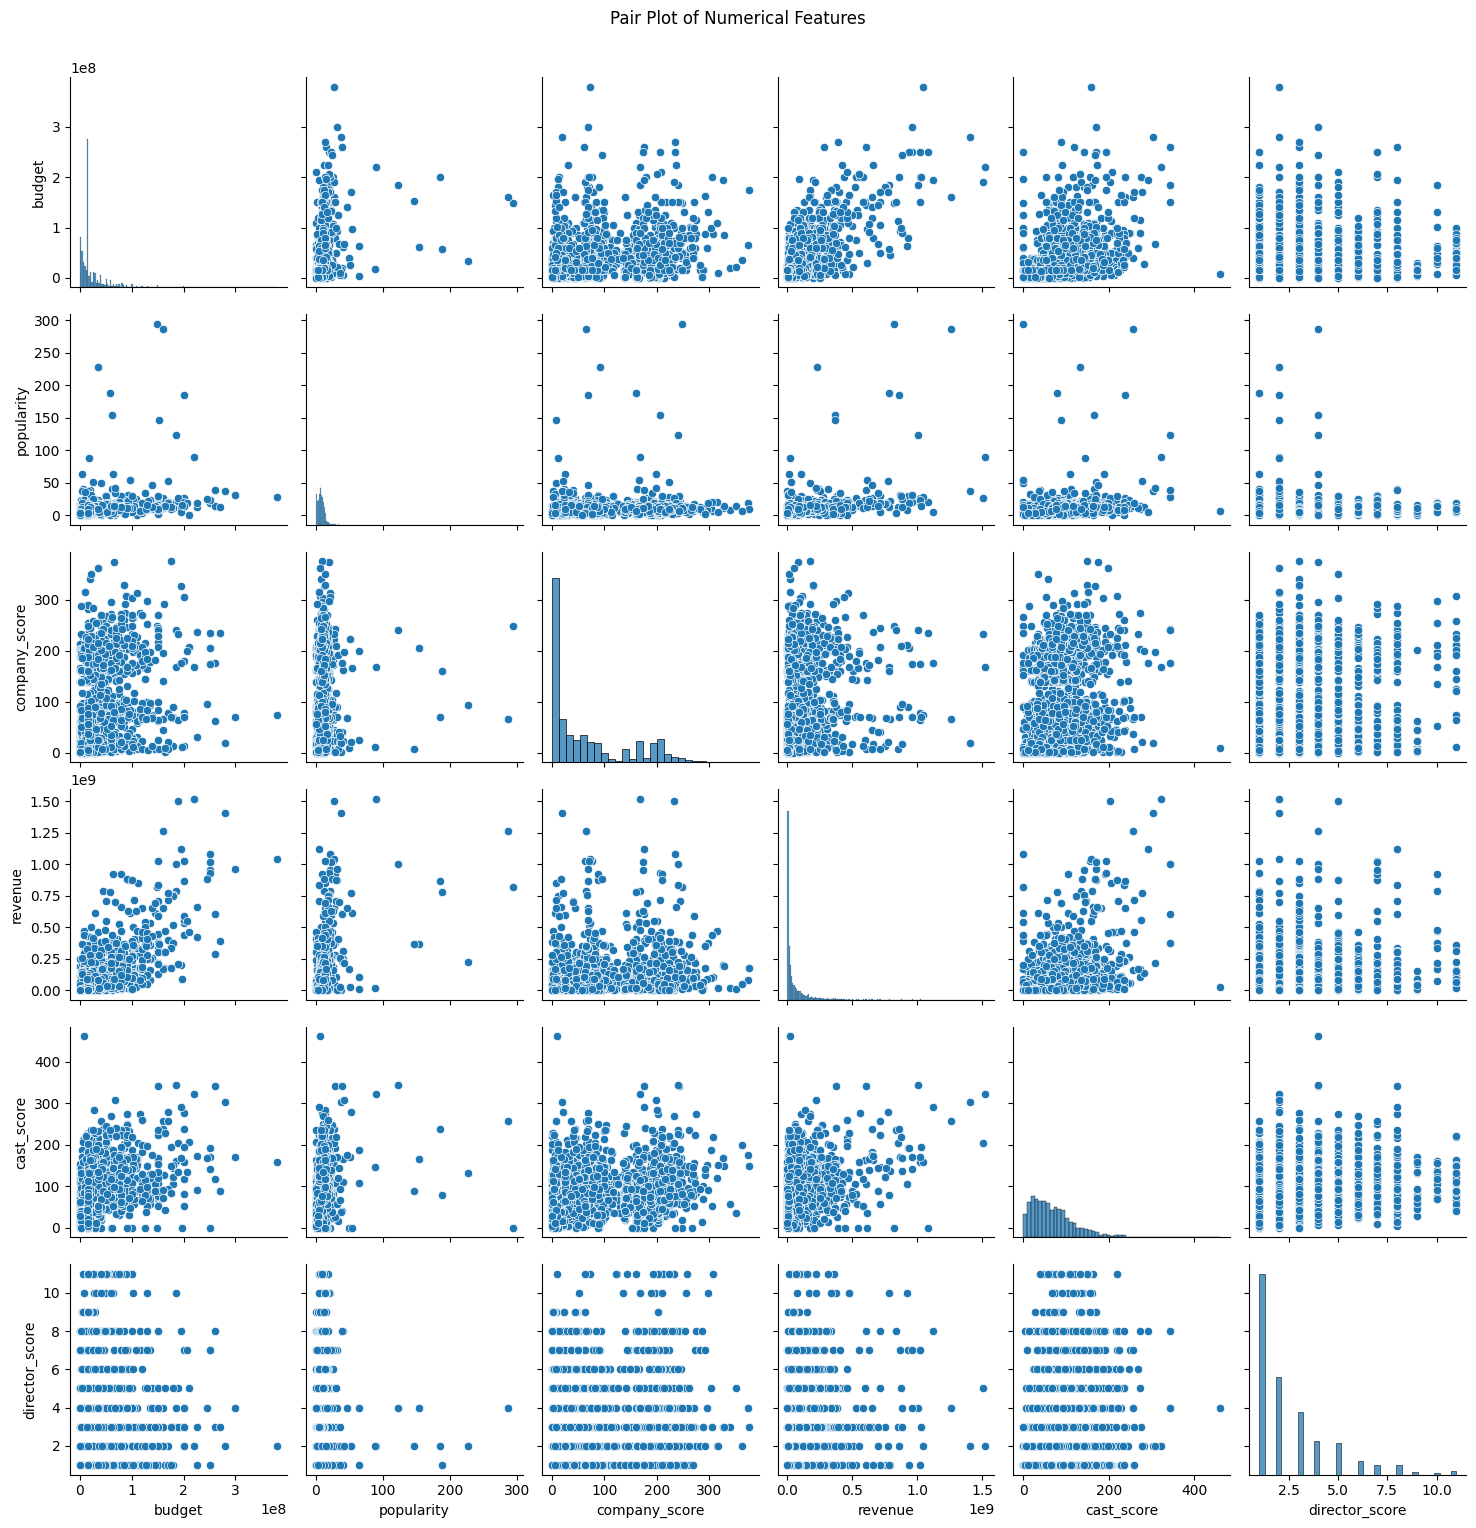

In [880]:
sns.pairplot(df[subset_cols])
plt.suptitle("Pair Plot of Numerical Features", y=1.02)
plt.show()

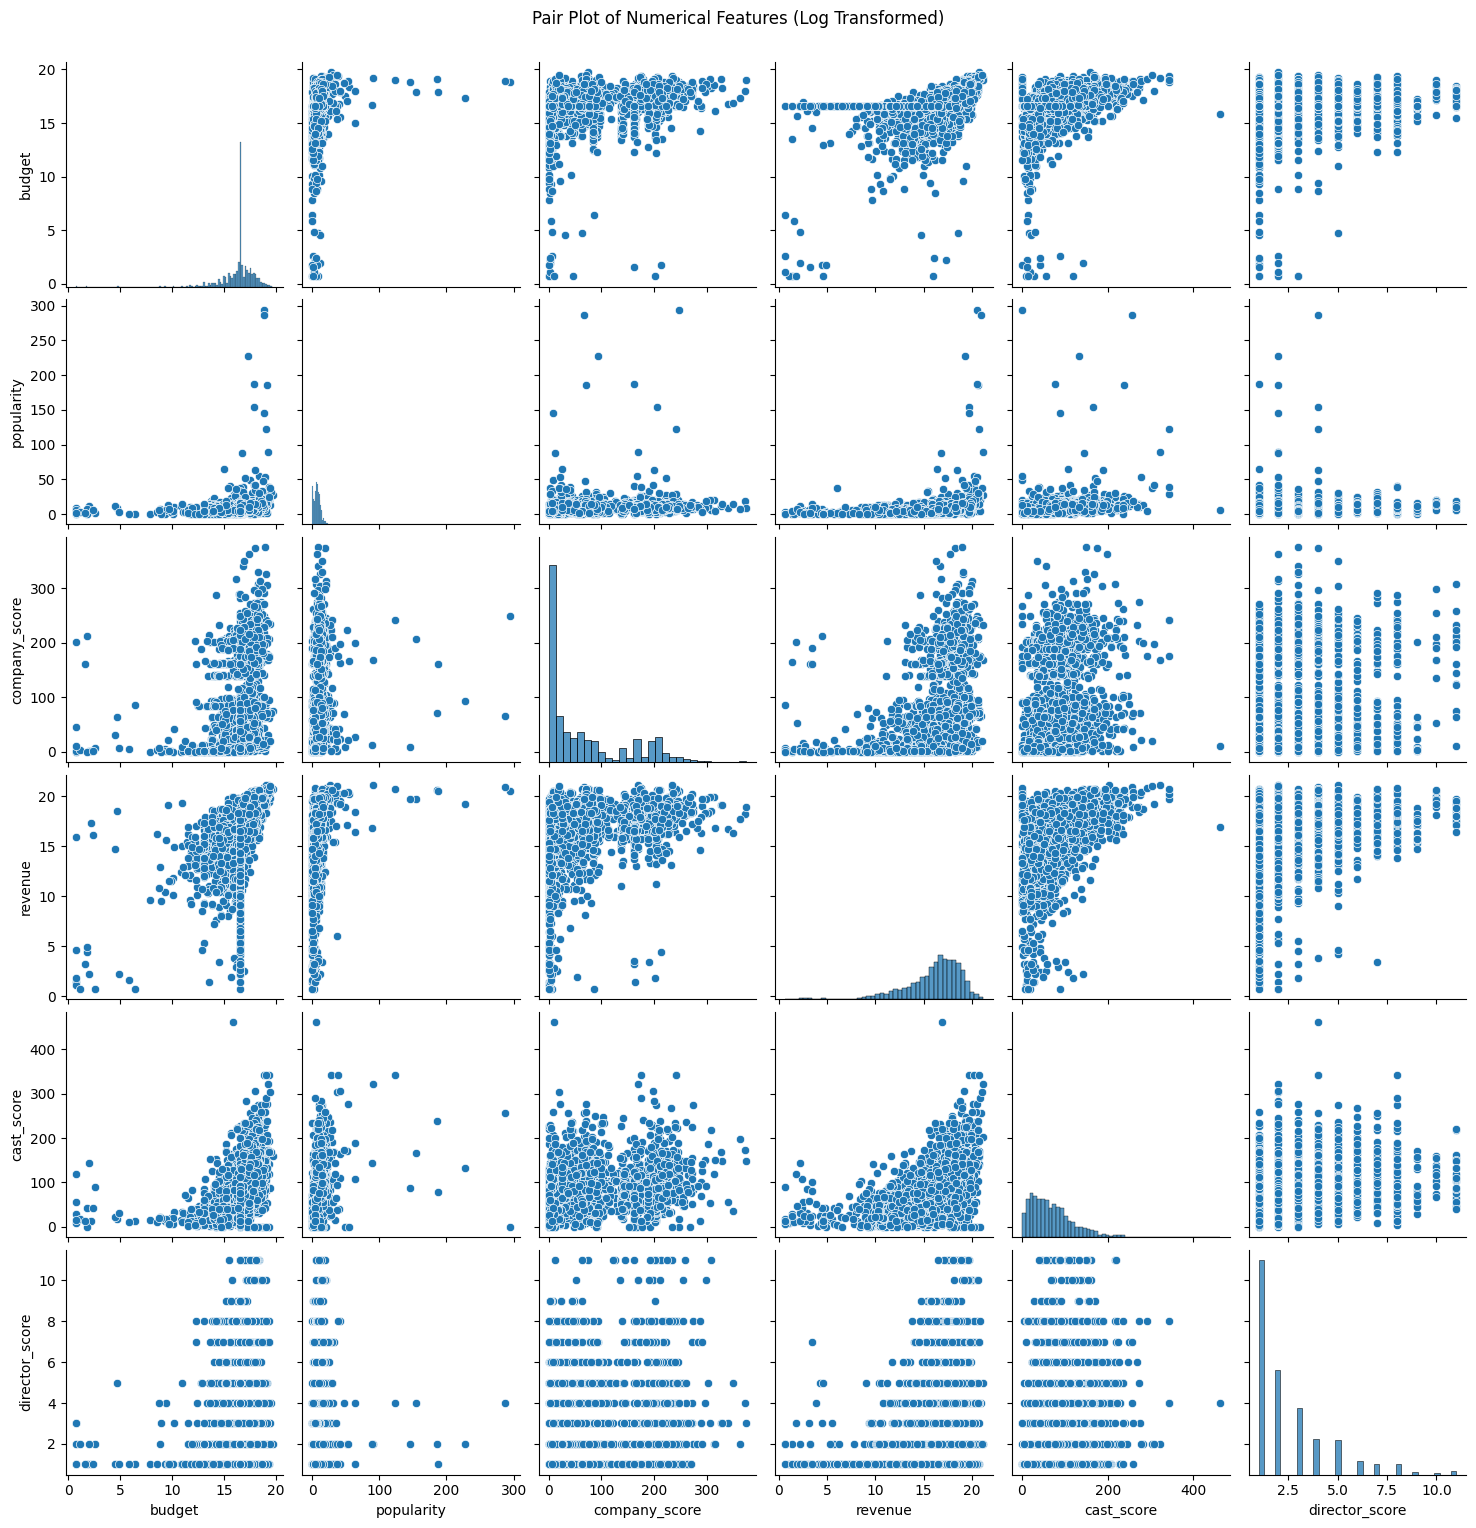

In [881]:
df_log = df[subset_cols].copy()
df_log['revenue'] = np.log1p(df_log['revenue'])
df_log['budget'] = np.log1p(df_log['budget'])

sns.pairplot(df_log)
plt.suptitle("Pair Plot of Numerical Features (Log Transformed)", y=1.02)
plt.show()

# feature engineering

## feature transformation

In [882]:
df['runtime'] = df['runtime'].replace(0, np.nan)
skewness = df[num_cols].skew()

print(skewness)

budget                  3.365873
popularity             14.377407
runtime                 1.662032
revenue                 4.542285
overview_length         1.148699
genre_count             0.496423
overview_word_count     1.145058
company_score           1.106804
top_company_score       1.343177
director_score          1.693568
keyword_score           1.906456
cast_score              1.344278
director_score          1.693568
dtype: float64


In [883]:
df['log_budget'] = np.sqrt(df['budget'])
df['log_revenue'] = np.log1p(df['revenue'])
df['log_popularity'] = np.log1p(df['popularity'])
df['runtime_log'] = np.log1p(df['runtime'])
df['log_overview_length']=np.log1p(df['overview_length'])
df['log_overview_word_count']=np.log1p(df['overview_word_count'])
df['log_top_company_score']=np.log1p(df['top_company_score'])
df['log_keyword_score'] = np.log1p(df['keyword_score'])
df['log_director_score'] = np.log1p(df['director_score'])
df['log_company_score'] = np.log1p(df['company_score'])
df['sqrt_cast_score'] = np.sqrt(df['cast_score'])

In [884]:
log_num_cols=['log_budget','log_revenue','log_popularity','runtime_log','log_overview_length','log_overview_word_count','log_top_company_score','log_keyword_score','log_director_score','log_company_score','sqrt_cast_score']
skewness = df[log_num_cols].skew()

print(skewness)

log_budget                 1.375309
log_revenue               -1.650536
log_popularity            -0.423864
runtime_log                0.001568
log_overview_length       -2.062791
log_overview_word_count   -0.955233
log_top_company_score      1.312198
log_keyword_score         -1.170916
log_director_score         0.777065
log_company_score         -0.274673
sqrt_cast_score            0.187525
dtype: float64


In [885]:
# cols = ['log_budget', 'log_popularity','log_overview_length','log_overview_word_count','log_top_company_score','log_keyword_score','log_company_score', 'log_revenue']

# for col in cols:
#     lower = df[col].quantile(0.01)
#     upper = df[col].quantile(0.99)
#     df[col] = df[col].clip(lower, upper)

In [886]:
skewness = df[log_num_cols].skew()

print(skewness)

log_budget                 1.375309
log_revenue               -1.650536
log_popularity            -0.423864
runtime_log                0.001568
log_overview_length       -2.062791
log_overview_word_count   -0.955233
log_top_company_score      1.312198
log_keyword_score         -1.170916
log_director_score         0.777065
log_company_score         -0.274673
sqrt_cast_score            0.187525
dtype: float64


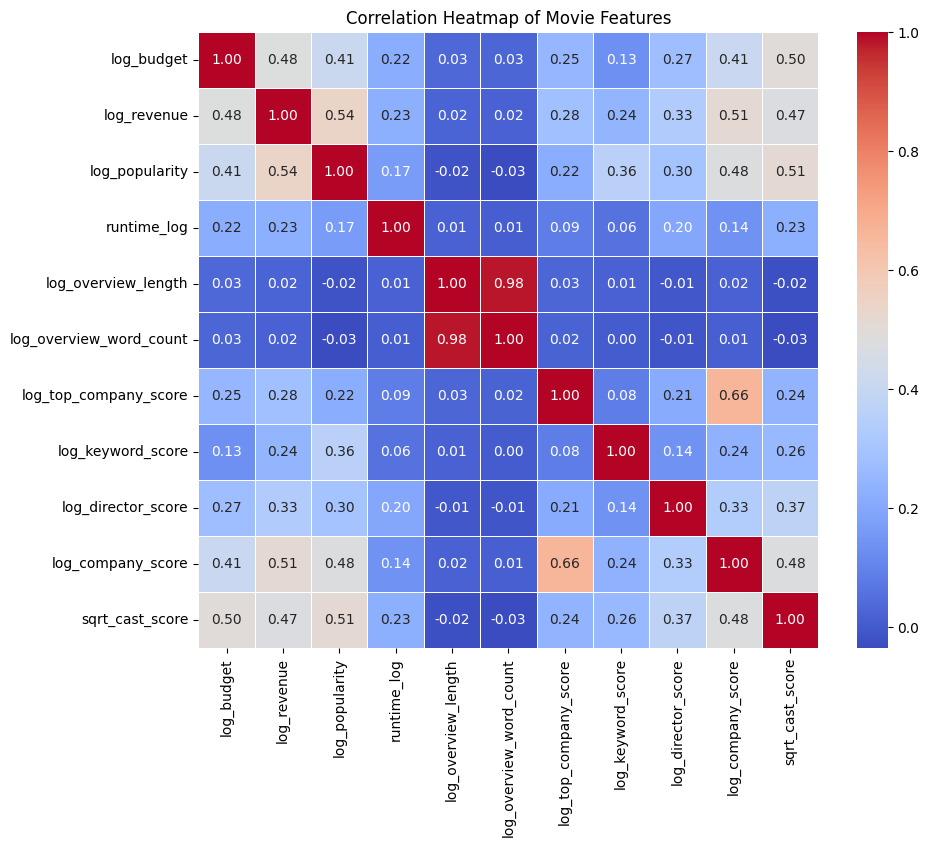

In [887]:
cols = log_num_cols

# Compute correlation matrix
corr_matrix = df[cols].corr()

# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Movie Features")
plt.show()

In [888]:
#cat col trans formation
target = 'log_revenue'

In [889]:
for col in cat_cols:
    pivot = pd.pivot_table(
        df,
        values=target,
        index=col,
        aggfunc='mean'
    )
    print(f"\nPivot for {col}:\n", pivot)


Pivot for has_collection:
                 log_revenue
has_collection             
0                 15.567722
1                 17.525986

Pivot for has_homepage:
               log_revenue
has_homepage             
0               15.664668
1               16.607538

Pivot for is_english:
             log_revenue
is_english             
0             14.498857
1             16.203473

Pivot for original_language_es:
                       log_revenue
original_language_es             
0                       15.981123
1                       14.645972

Pivot for original_language_fr:
                       log_revenue
original_language_fr             
0                       16.021782
1                       13.721944

Pivot for original_language_hi:
                       log_revenue
original_language_hi             
0                       15.970197
1                       15.383697

Pivot for original_language_other:
                          log_revenue
original_language_other   

In [890]:
for col in cat_cols:
    corr, p = pearsonr(df[col], df['log_revenue'])

    print("Correlation:",col, corr)
    print("P-value:", p)

Correlation: has_collection 0.2565527363245794
P-value: 2.680284671303395e-46
Correlation: has_homepage 0.14313349218843643
P-value: 3.3515603636160184e-15
Correlation: is_english 0.19420189956151376
P-value: 6.98727163770945e-27
Correlation: original_language_es -0.05184823467291972
P-value: 0.0045032725746496525
Correlation: original_language_fr -0.11957167642032711
P-value: 5.0293604185004845e-11
Correlation: original_language_hi -0.022513128622817125
P-value: 0.2176738361051115
Correlation: original_language_other -0.11214678618497828
P-value: 7.301590153542187e-10
Correlation: original_language_ru -0.08823553485842273
P-value: 1.2965111471350339e-06
Correlation: is_top_company 0.28583986372065456
P-value: 1.6462891531560316e-57
Correlation: usa_produced 0.2999315273894304
P-value: 2.0770528121555462e-63
Correlation: has_english 0.22932194358900415
P-value: 4.284250341285448e-37
Correlation: has_keywords 0.25083451167061444
P-value: 2.8616731058756504e-44


In [891]:
df['movie_age'] = 2026 - df['release_year']
df['movie_age'] = df['movie_age'].clip(lower=0)  # remove negatives
df['movie_age_log'] = np.log1p(df['movie_age'])

In [892]:
df['is_peak_season'] = df['release_month'].isin([5,6,7,11,12]).astype(int)

In [893]:
df['is_friday_release'] = (df['release_dayofweek'] == 4).astype(int)

In [894]:
log_num_cols.extend(cat_cols)

In [895]:
log_num_cols.extend(['movie_age_log','is_peak_season','is_friday_release'])

In [896]:
df = df[log_num_cols]
drop_cols = [
    'original_language_es',
    'original_language_fr',
    'original_language_hi',
    'original_language_ru',
    'original_language_other'
]
df = df.drop(columns=drop_cols)
df.head()

,log_budget,log_revenue,log_popularity,runtime_log,log_overview_length,log_overview_word_count,log_top_company_score,log_keyword_score,log_director_score,log_company_score,...,has_collection,has_homepage,is_english,is_top_company,usa_produced,has_english,has_keywords,movie_age_log,is_peak_season,is_friday_release
0,3741.657387,16.326300,2.024905,4.543295,5.049856,3.401197,0.693147,5.429346,1.386294,5.669881,...,1,0,1,1,1,1,1,2.484907,0,1
1,6324.555320,18.370959,2.224504,4.736198,5.976351,4.248495,0.000000,3.555348,1.945910,4.143135,...,1,0,1,0,1,1,1,3.135494,0,1
2,1816.590212,16.387512,4.178992,4.663439,4.875197,3.091042,0.000000,5.087596,0.693147,3.295837,...,0,1,1,0,1,1,1,2.564949,0,1
3,1095.445115,16.588099,1.429099,4.812184,6.366470,4.672829,0.000000,3.912023,0.693147,0.000000,...,0,1,0,0,0,1,1,2.708050,0,1
4,4000.000000,15.182615,0.764570,4.779123,5.129899,3.496508,0.000000,0.000000,0.693147,0.000000,...,0,0,0,0,0,0,0,2.890372,0,0


## feature creation

In [897]:
df['budget_popularity'] = df['log_budget'] * df['log_popularity']
df['collection_popularity'] = df['has_collection'] * df['log_popularity']
df['company_director'] = df['log_company_score'] * df['log_director_score']
df['budget_director'] = df['log_budget'] * df['log_director_score']
df['budget_cast'] = df['log_budget'] * df['sqrt_cast_score']

df['popularity_season'] = df['log_popularity'] * df['is_peak_season']

df['age_popularity'] = df['movie_age_log'] * df['log_popularity']
df['budget_collection'] = df['log_budget'] * df['has_collection']
df['runtime_keywords'] = df['runtime_log'] * df['log_keyword_score']

In [898]:
df['budget_per_company'] = df['log_budget'] / (df['log_company_score'] + 1)
df['words_per_char'] = df['log_overview_word_count'] / (df['log_overview_length'] + 1)

In [899]:
df.skew()

log_budget                 1.375309
log_revenue               -1.650536
log_popularity            -0.423864
runtime_log                0.001568
log_overview_length       -2.062791
log_overview_word_count   -0.955233
log_top_company_score      1.312198
log_keyword_score         -1.170916
log_director_score         0.777065
log_company_score         -0.274673
sqrt_cast_score            0.187525
has_collection             1.490367
has_homepage               0.795264
is_english                -2.056234
is_top_company             1.295043
usa_produced              -1.222458
has_english               -2.237034
has_keywords              -2.824688
movie_age_log             -2.236005
is_peak_season             0.474356
is_friday_release          0.225531
budget_popularity          2.325342
collection_popularity      1.849117
company_director           0.834187
budget_director            1.963807
budget_cast                2.189545
popularity_season          0.921399
age_popularity            -0

In [900]:
X = df.drop(columns=['log_revenue'])  
y = df['log_revenue']   

In [901]:
X = X.replace([np.inf, -np.inf], np.nan)

X_scaled = X.fillna(X.median())


In [902]:
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)

In [903]:
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [904]:
X_scaled.head()

,log_budget,log_popularity,runtime_log,log_overview_length,log_overview_word_count,log_top_company_score,log_keyword_score,log_director_score,log_company_score,sqrt_cast_score,...,collection_popularity,company_director,budget_director,budget_cast,popularity_season,age_popularity,budget_collection,runtime_keywords,budget_per_company,words_per_char
0,3741.657387,2.024905,4.543295,5.049856,3.401197,0.693147,5.429346,1.386294,5.669881,10.049876,...,2.024905,7.860124,5187.038537,37603.191354,0.0,5.031700,3741.657387,24.667118,560.978139,0.562195
1,6324.555320,2.224504,4.736198,5.976351,4.248495,0.000000,3.555348,1.945910,4.143135,9.746794,...,2.224504,8.062168,12307.016386,61644.140030,0.0,6.974920,6324.555320,16.838834,1229.708273,0.608985
2,1816.590212,4.178992,4.663439,4.875197,3.091042,0.000000,5.087596,0.693147,3.295837,10.392305,...,0.000000,2.284500,1259.164384,18878.559267,0.0,10.718903,0.000000,23.725696,422.872253,0.526117
3,1095.445115,1.429099,4.812184,6.366470,4.672829,0.000000,3.912023,0.693147,0.000000,3.316625,...,0.000000,0.000000,759.304693,3633.180425,0.0,3.870072,0.000000,18.825376,1095.445115,0.634338
4,4000.000000,0.764570,4.779123,5.129899,3.496508,0.000000,0.000000,0.693147,0.000000,2.236068,...,0.000000,0.000000,2772.588722,8944.271910,0.0,2.209891,0.000000,0.000000,4000.000000,0.570402


In [905]:
X_scaled.columns

Index(['log_budget', 'log_popularity', 'runtime_log', 'log_overview_length',
       'log_overview_word_count', 'log_top_company_score', 'log_keyword_score',
       'log_director_score', 'log_company_score', 'sqrt_cast_score',
       'has_collection', 'has_homepage', 'is_english', 'is_top_company',
       'usa_produced', 'has_english', 'has_keywords', 'movie_age_log',
       'is_peak_season', 'is_friday_release', 'budget_popularity',
       'collection_popularity', 'company_director', 'budget_director',
       'budget_cast', 'popularity_season', 'age_popularity',
       'budget_collection', 'runtime_keywords', 'budget_per_company',
       'words_per_char'],
      dtype='object')

# model training

In [906]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [907]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [908]:
y_pred = model.predict(X_test)

In [909]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 2.1116761308619196
R² Score: 0.4996666224876125


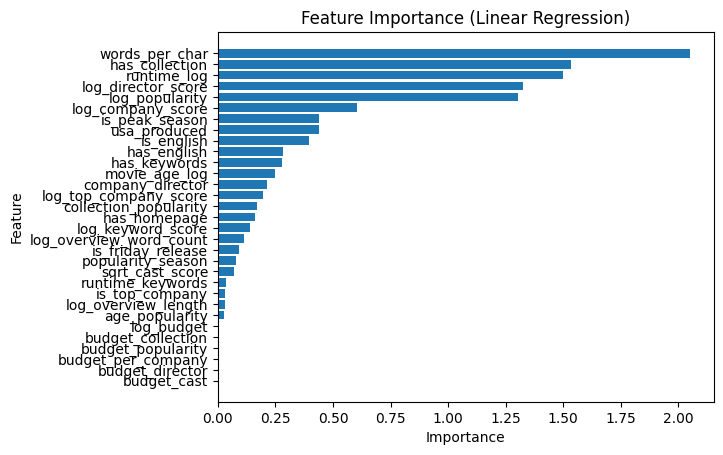

In [910]:
coefficients = model.coef_

# Create DataFrame
feature_importance = pd.DataFrame({
    'Feature': X_scaled.columns,
    'Importance': np.abs(coefficients)
})

# Sort
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

# Plot
plt.figure()
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance (Linear Regression)")
plt.gca().invert_yaxis()
plt.show()

In [911]:

scores = cross_val_score(model, X_scaled, y, cv=5, scoring='r2')
print(scores.mean())

0.4521371210811168


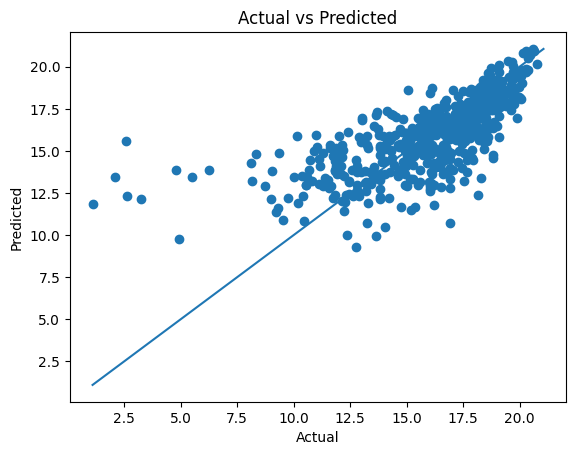

In [912]:
plt.figure()
plt.scatter(y_test, y_pred)

# Diagonal line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val])  # y = x line

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")

plt.show()

In [913]:
top_features = feature_importance['Feature'].head(10)

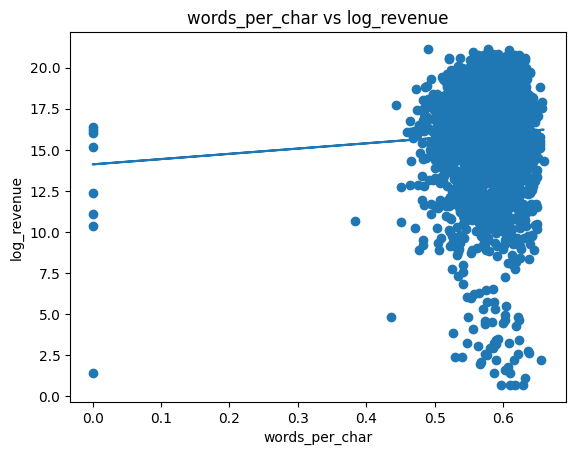

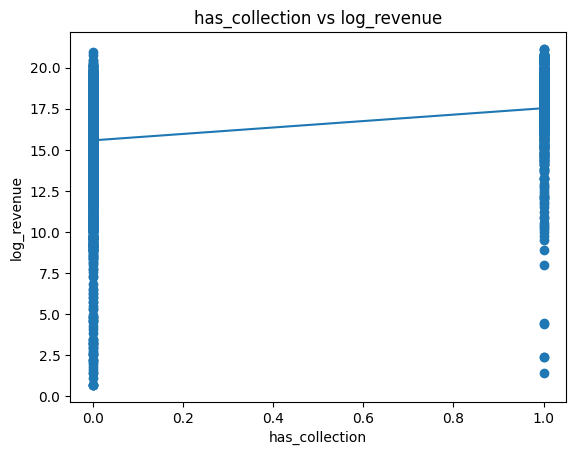

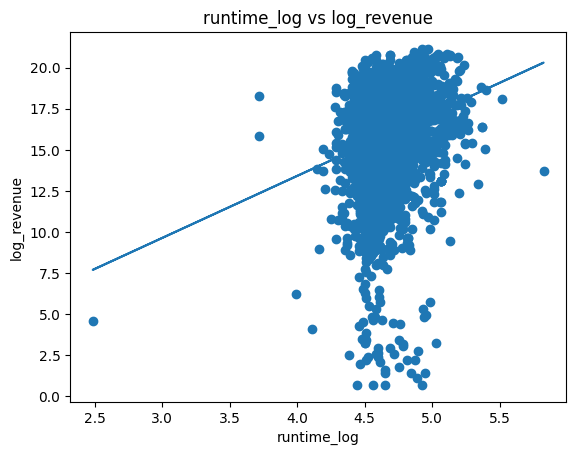

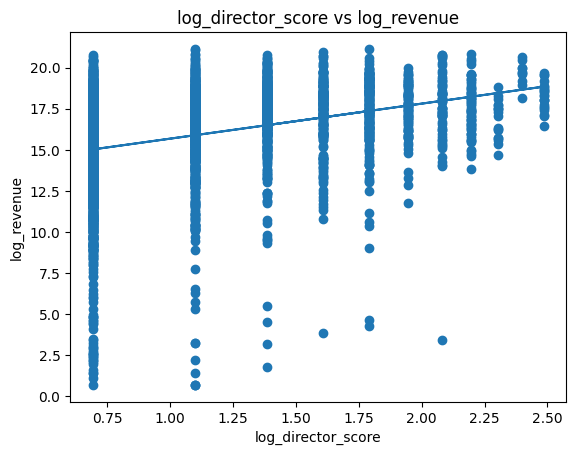

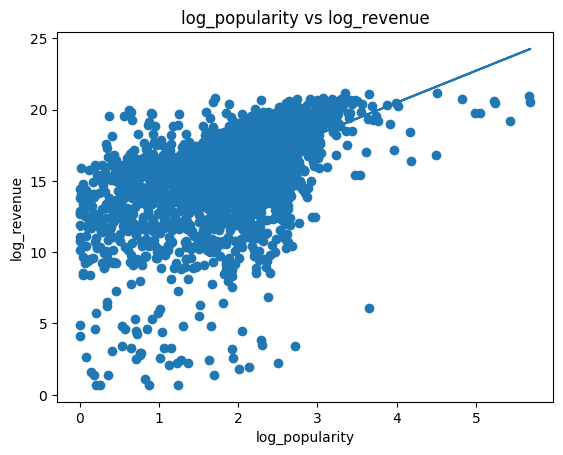

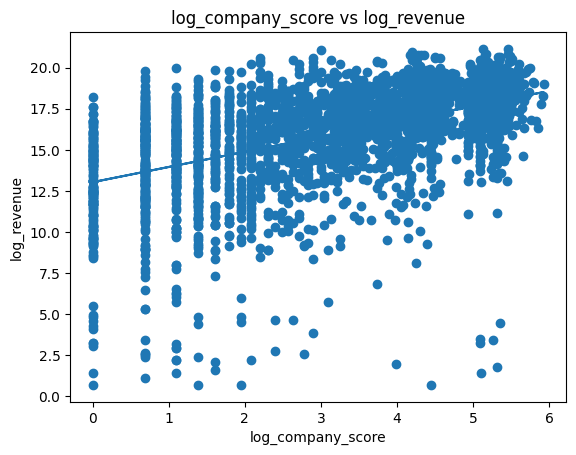

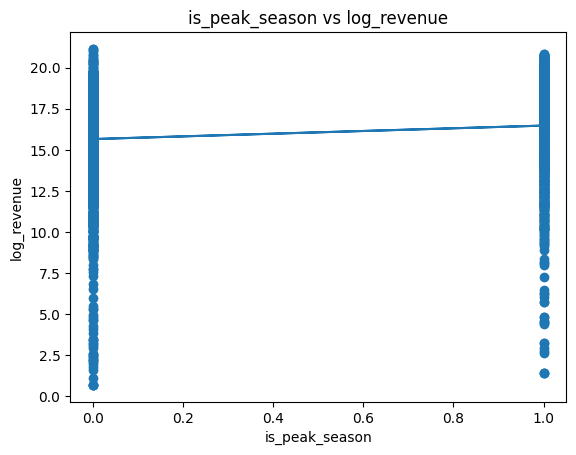

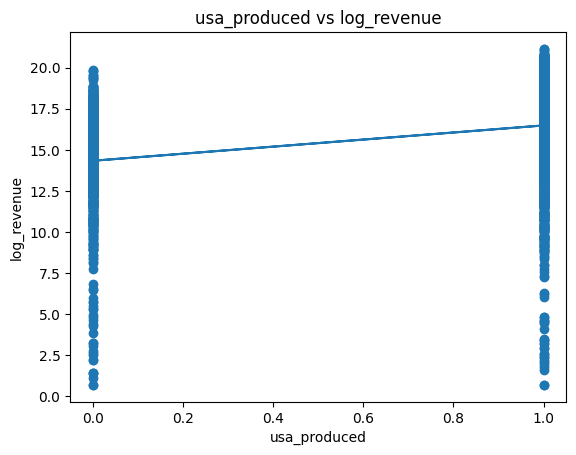

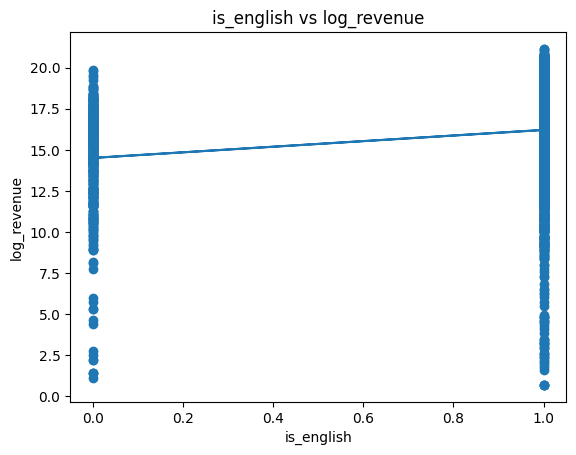

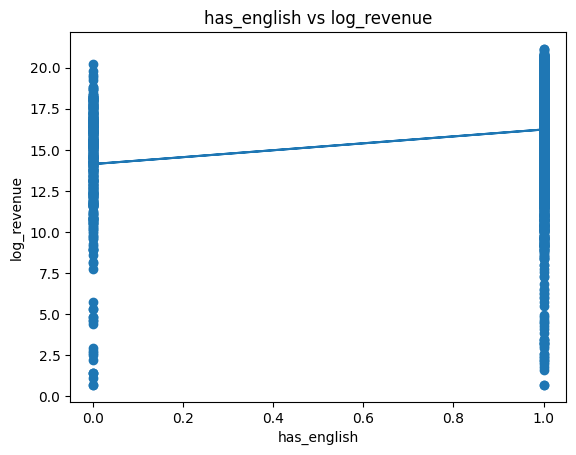

In [914]:
for feature in top_features:
    plt.figure()
    plt.scatter(X_scaled[feature], y)

    # regression line
    z = np.polyfit(X_scaled[feature], y, 1)
    p = np.poly1d(z)

    plt.plot(X_scaled[feature], p(X_scaled[feature]))

    plt.xlabel(feature)
    plt.ylabel("log_revenue")
    plt.title(f"{feature} vs log_revenue")

    plt.show()

In [915]:
X_train_top_feat=X_train[top_features]
X_test_top_feat=X_test[top_features]
X_train_top_feat.head()

,words_per_char,has_collection,runtime_log,log_director_score,log_popularity,log_company_score,is_peak_season,usa_produced,is_english,has_english
642,0.591031,0,4.762174,1.386294,2.178165,5.099866,1,1,1,1
700,0.613247,0,4.553877,1.609438,2.129324,5.318120,1,1,1,1
226,0.610321,0,4.663439,1.098612,2.159734,4.143135,0,1,1,1
1697,0.607477,0,4.890349,1.098612,1.925754,4.962845,0,1,1,1
1010,0.537500,0,4.836282,1.609438,2.907483,5.347108,1,1,1,1


In [916]:
model_top_feat=LinearRegression()
model_top_feat.fit(X_train_top_feat, y_train)

LinearRegression()

In [917]:

y_pred_top_feat = model_top_feat.predict(X_test_top_feat)

In [918]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred_top_feat))
r2 = r2_score(y_test, y_pred_top_feat)

print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 2.182594716090196
R² Score: 0.46549588517460605


In [919]:
X1=X_scaled[top_features]

scores = cross_val_score(model_top_feat, X1, y, cv=5, scoring='r2')
print(scores.mean())

0.4176958571005189


In [920]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor( n_estimators=500,
    max_depth=6,
    min_samples_split=16,
    min_samples_leaf=12,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [921]:
y_train_pred = model.predict(X_train)
rmse = np.sqrt(mean_squared_error( y_train,y_train_pred))
r2 = r2_score(y_train, y_train_pred)

print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 2.0466625553675963
R² Score: 0.5578931590611179


In [922]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 2.0403890975843995
R² Score: 0.5328774397381851


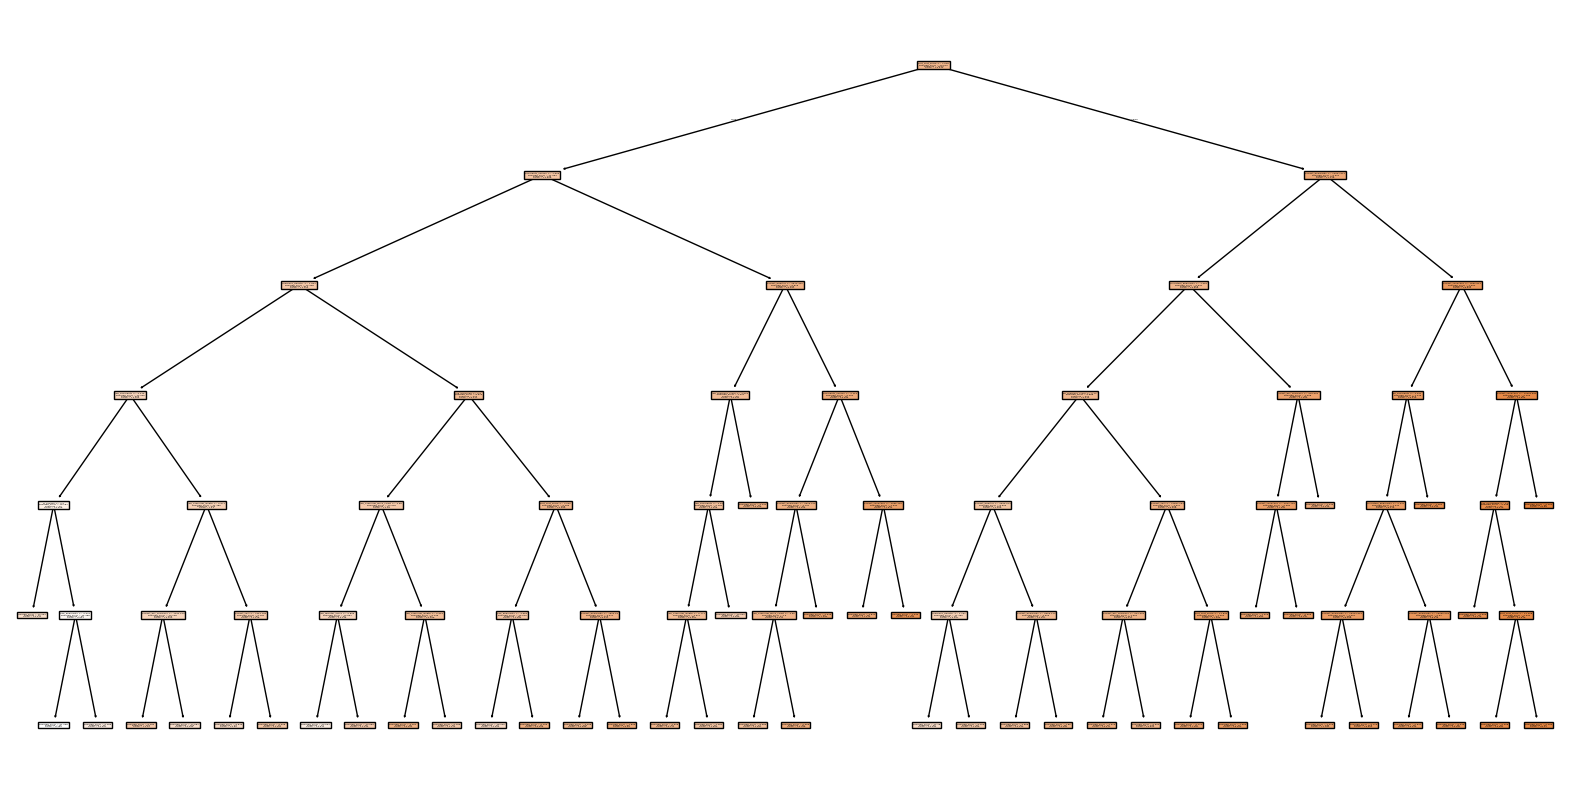

In [923]:
# pick one tree
tree = model.estimators_[0]  
plt.figure(figsize=(20,10))
plot_tree(tree, feature_names=X_scaled.columns, filled=True)
plt.show()

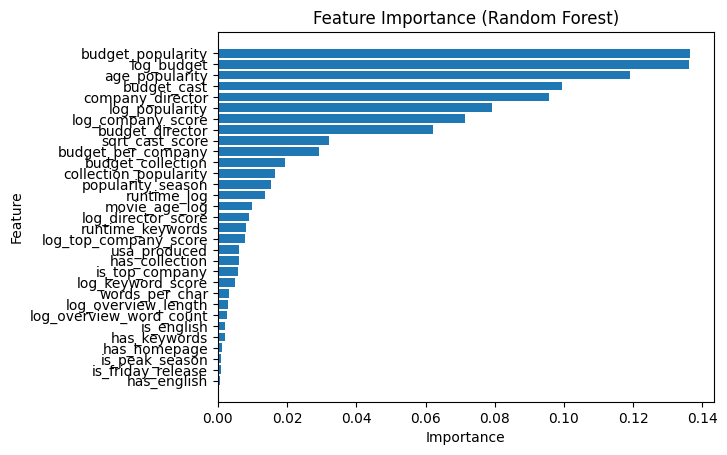

In [924]:
# Get importance
importances = model.feature_importances_

# Create DataFrame
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure()
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance (Random Forest)")
plt.gca().invert_yaxis()
plt.show()

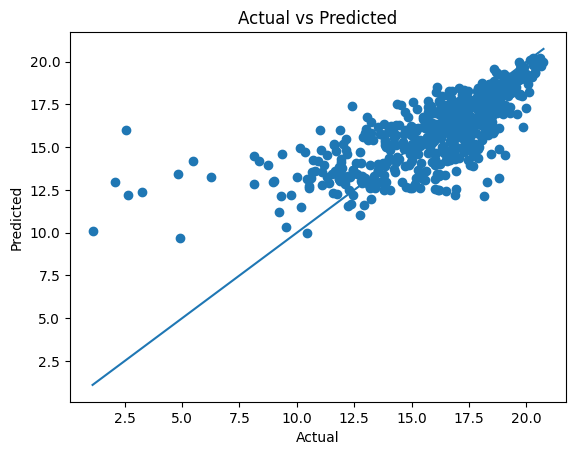

In [925]:
plt.figure()
plt.scatter(y_test, y_pred)

# Diagonal line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val])  # y = x line

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")

plt.show()

In [926]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=500,          
    max_depth=3,
    learning_rate=0.02,
    colsample_bytree=0.9,      
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [927]:
y_train_pred = model.predict(X_train)
rmse = np.sqrt(mean_squared_error( y_train,y_train_pred))
r2 = r2_score(y_train, y_train_pred)

print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 1.7424237941402798
R² Score: 0.6795632390546569


In [928]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 1.971870919451003
R² Score: 0.5637235019907854


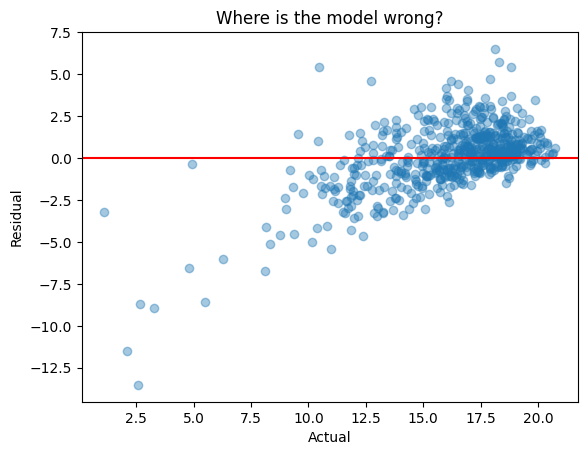

         actual  predicted      error
450    2.564949  16.090704  13.525755
1190   2.079442  13.606331  11.526889
498    3.258097  12.167001   8.908904
2759   2.639057  11.344039   8.704982
152    5.488938  14.054259   8.565322
96     8.119399  14.873257   6.753858
1161   4.804021  11.376520   6.572499
2645  18.146244  11.635357   6.510887
1055   6.265301  12.260664   5.995363
1756  18.300304  12.582816   5.717488
761   10.988846  16.431103   5.442257
254   10.453342   5.011091   5.442250
104   18.822951  13.383195   5.439756
1025   8.339979  13.476191   5.136212
1793  10.144942  15.177464   5.032521
2366  17.904843  13.189040   4.715802
1607  12.392465  17.045706   4.653241
457   12.737136   8.148812   4.588324
1178  16.213406  11.643596   4.569810
313    8.747987  13.315078   4.567090


In [929]:
y_pred = model.predict(X_test)
residuals = y_test - y_pred

# Plot residuals vs actual
plt.scatter(y_test, residuals, alpha=0.4)
plt.axhline(0, color='red')
plt.xlabel("Actual")
plt.ylabel("Residual")
plt.title("Where is the model wrong?")
plt.show()

# Find worst predictions
error_df = pd.DataFrame({
    'actual': y_test,
    'predicted': y_pred,
    'error': residuals.abs()
}).sort_values('error', ascending=False)

print(error_df.head(20))


<Figure size 1000x1000 with 0 Axes>

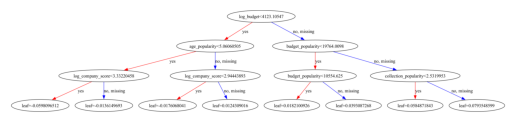

In [930]:
from xgboost import plot_tree
# pick one tree
plt.figure(figsize=(10, 10))
plot_tree(model, num_trees=0)  # first tree
plt.show()

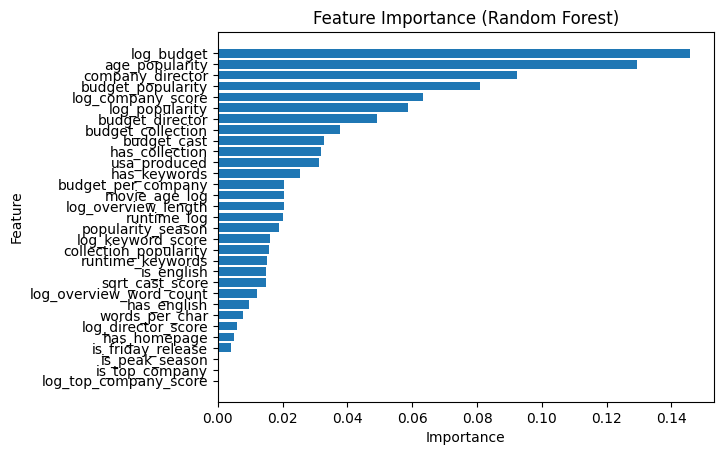

In [931]:
# Get importance
importances = model.feature_importances_

# Create DataFrame
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure()
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance (Random Forest)")
plt.gca().invert_yaxis()
plt.show()

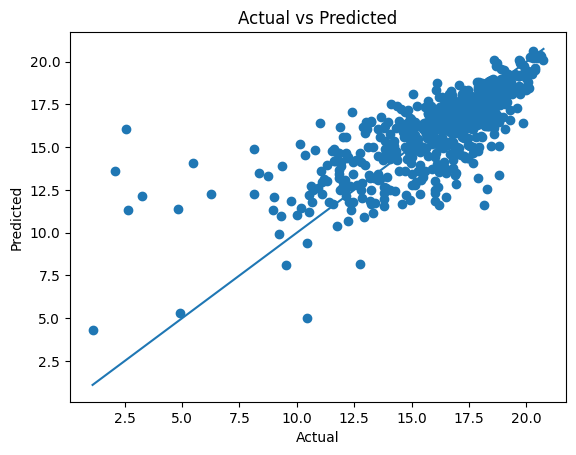

In [932]:
plt.figure()
plt.scatter(y_test, y_pred)

# Diagonal line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val])  # y = x line

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")

plt.show()

In [933]:
from sklearn.svm import SVR

model = SVR(kernel='rbf', C=1.0, epsilon=0.1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [934]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 2.3538067263261375
R² Score: 0.3783492626227476


## base models
random forest, xgboost

ploting

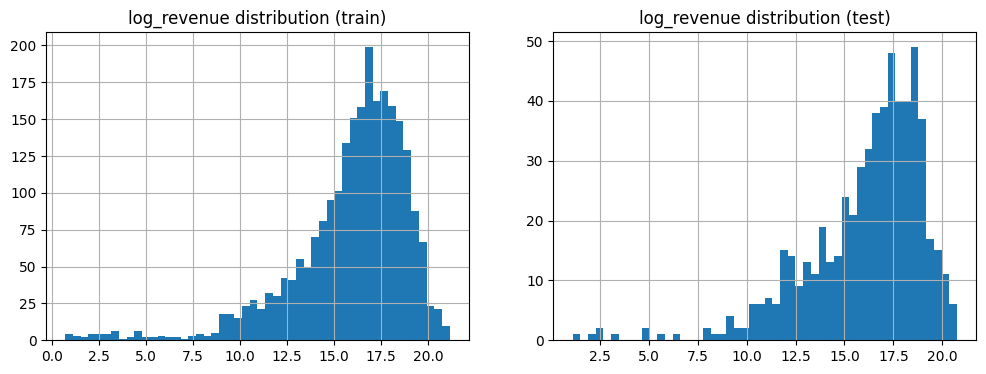

In [935]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

y_train.hist(bins=50, ax=axes[0])
axes[0].set_title("log_revenue distribution (train)")

y_test.hist(bins=50, ax=axes[1])
axes[1].set_title("log_revenue distribution (test)")

plt.show()

In [936]:
print(y_train.describe())
print(f"\nSkewness: {y_train.skew():.3f}")
print(f"Values below 10: {(y_train < 10).sum()}")
print(f"Values above 22: {(y_train > 22).sum()}")

count    2400.000000
mean       15.922417
std         3.078741
min         0.693147
25%        14.647104
50%        16.578551
75%        18.005173
max        21.141685
Name: log_revenue, dtype: float64

Skewness: -1.675
Values below 10: 108
Values above 22: 0


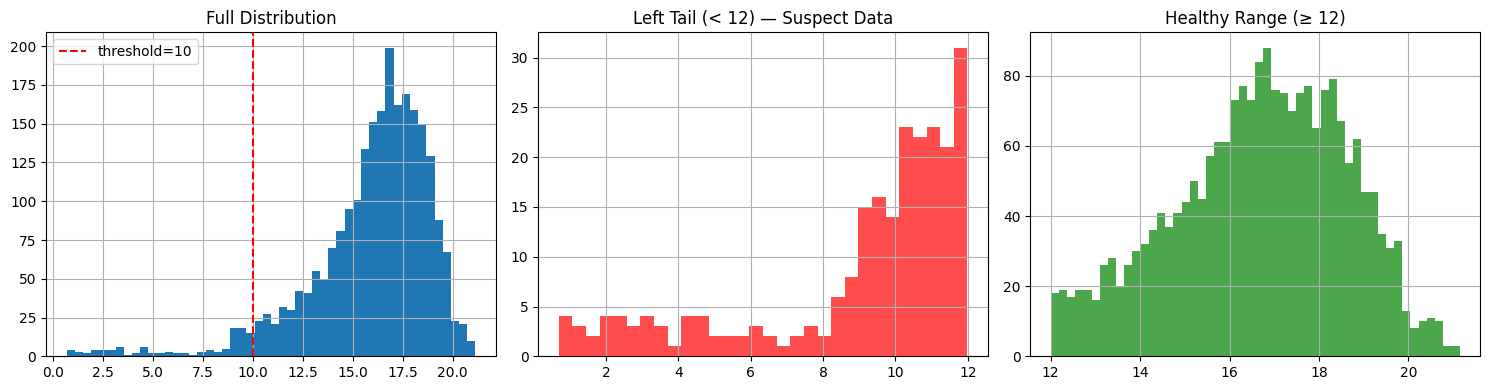

In [937]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Full distribution
y_train.hist(bins=50, ax=axes[0])
axes[0].set_title("Full Distribution")
axes[0].axvline(10, color='red', linestyle='--', label='threshold=10')
axes[0].legend()

# Just the left tail
y_train[y_train < 12].hist(bins=30, ax=axes[1], color='red', alpha=0.7)
axes[1].set_title("Left Tail (< 12) — Suspect Data")

# Healthy range
y_train[y_train >= 12].hist(bins=50, ax=axes[2], color='green', alpha=0.7)
axes[2].set_title("Healthy Range (≥ 12)")

plt.tight_layout()
plt.show()

In [938]:
suspect = df[df['log_revenue'] < 10].copy()

print(suspect[[
    'log_budget', 'log_popularity', 
    'log_revenue', 'log_company_score',
    'is_english', 'has_collection'
]].describe())

# Real revenue values
print("\nActual revenue values:")
print(np.exp(suspect['log_revenue']).describe())

print(f"\nHave non-zero budget: {(suspect['log_budget'] > 0).sum()}")
print(f"Mean popularity:      {suspect['log_popularity'].mean():.3f}")
print(f"vs full dataset:      {df['log_popularity'].mean():.3f}")

        log_budget  log_popularity  log_revenue  log_company_score  \
count   128.000000      128.000000   128.000000         128.000000   
mean   3013.811024        1.169022     6.612806           1.520069   
std    1519.154919        0.758693     3.015264           1.381771   
min       1.000000        0.001878     0.693147           0.000000   
25%    1895.031854        0.563065     3.761738           0.693147   
50%    4000.000000        1.076609     8.063549           1.098612   
75%    4000.000000        1.825194     9.244184           2.197225   
max    4795.831523        3.650258     9.991224           5.361292   

       is_english  has_collection  
count  128.000000      128.000000  
mean     0.765625        0.078125  
std      0.425272        0.269423  
min      0.000000        0.000000  
25%      1.000000        0.000000  
50%      1.000000        0.000000  
75%      1.000000        0.000000  
max      1.000000        1.000000  

Actual revenue values:
count      128.000000

In [939]:
# Stage 1 — Remove true garbage (revenue < e^10 = $22,000)
df_clean = df[df['log_revenue'] >= 10].copy()
print(f"Removed {len(df) - len(df_clean)} rows")  # should be ~108

# Stage 2 — Winsorize remaining left tail only (not right)
lower = df_clean['log_revenue'].quantile(0.05)
df_clean['log_revenue'] = df_clean['log_revenue'].clip(lower=lower)
# No upper clip — your max of 20.43 is perfectly fine

print(df_clean['log_revenue'].describe())
print(f"New skewness: {df_clean['log_revenue'].skew():.3f}")

Removed 128 rows
count    2872.000000
mean       16.421190
std         2.208376
min        11.829118
25%        15.016277
50%        16.739358
75%        18.111529
max        21.141685
Name: log_revenue, dtype: float64
New skewness: -0.465


In [940]:
print("Genres in removed rows:")
print(suspect['is_english'].value_counts())
print(suspect['has_collection'].value_counts())

Genres in removed rows:
is_english
1    98
0    30
Name: count, dtype: int64
has_collection
0    118
1     10
Name: count, dtype: int64


In [941]:
df=df[df['log_revenue'] >=10].copy()
X_scaled=df.drop(columns=['log_revenue'])
y=df['log_revenue']
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor( n_estimators=500,
    max_depth=6,
    min_samples_split=16,
    min_samples_leaf=12,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_train_pred = model.predict(X_train)
rmse = np.sqrt(mean_squared_error( y_train,y_train_pred))
r2 = r2_score(y_train, y_train_pred)

print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 1.3974342424193524
R² Score: 0.6262586510897306


In [942]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 1.5481389773820635
R² Score: 0.5774331061807951


In [943]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=500,          
    max_depth=3,
    learning_rate=0.02,
    colsample_bytree=0.9,      
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [944]:
y_pred = model.predict(X_test)
y_train_pred = model.predict(X_train)
rmse = np.sqrt(mean_squared_error( y_train,y_train_pred))
r2 = r2_score(y_train, y_train_pred)

print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 1.2709372558715168
R² Score: 0.6908589994289469


In [945]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 1.4842573439950275
R² Score: 0.6115867898989931


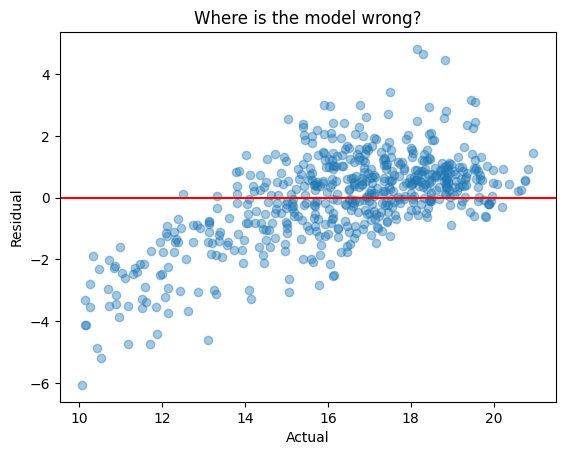

         actual  predicted     error
2600  10.068960  16.137751  6.068791
2276  10.531403  15.740559  5.209156
1499  10.411690  15.285467  4.873777
2645  18.146244  13.331871  4.814373
2939  11.695255  16.453949  4.758694
2289  11.175619  15.919372  4.743753
1756  18.300304  13.660278  4.640026
1319  13.112927  17.726122  4.613195
827   18.826146  14.373034  4.453112
2069  11.870607  16.302706  4.432099
299   10.168003  14.299867  4.131863
1356  10.126671  14.248399  4.121728
2789  10.943322  14.823793  3.880471
483   12.142467  15.893306  3.750839
435   12.614400  16.297749  3.683348
1180  11.519504  15.100070  3.580566
1173  10.249981  13.801785  3.551804
1839  11.841610  15.392167  3.550557
436   11.169294  14.692062  3.522769
1361  10.716660  14.214332  3.497672


In [946]:
y_pred = model.predict(X_test)
residuals = y_test - y_pred

# Plot residuals vs actual
plt.scatter(y_test, residuals, alpha=0.4)
plt.axhline(0, color='red')
plt.xlabel("Actual")
plt.ylabel("Residual")
plt.title("Where is the model wrong?")
plt.show()

# Find worst predictions
error_df = pd.DataFrame({
    'actual': y_test,
    'predicted': y_pred,
    'error': residuals.abs()
}).sort_values('error', ascending=False)

print(error_df.head(20))


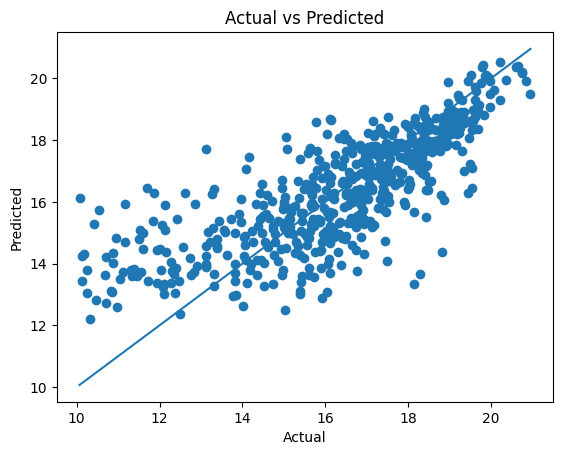

In [947]:
plt.figure()
plt.scatter(y_test, y_pred)

# Diagonal line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val])  # y = x line

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")

plt.show()